# Prediksi Ketinggian Muka Air (Tinggi Muka Air - TMA) Menggunakan Gradient Boosting
## Water Level Prediction (Tinggi Muka Air - TMA) using Gradient Boosting

Notebook ini mengimplementasikan pipeline pembelajaran mesin (machine learning) untuk memprediksi Tinggi Muka Air (TMA) di berbagai pos pemantauan. Model yang digunakan adalah algoritma gradient boosting berbasis tabel (LightGBM, XGBoost, CatBoost). 

### Komponen Utama (Key Components):
1. **Analisis Eksplorasi Data (EDA)**: Memahami karakteristik pencilan (outliers), data hilang, pola musiman, dan lag autokorelasi.
2. **Pembersihan & Imputasi Data**: Membersihkan data tanpa menimbulkan kebocoran data (data leakage).
3. **Rekayasa Fitur (Feature Engineering)**: Membuat fitur lag, statistik bergulir, indeks hidrologi fisik (Antecedent Precipitation Index), interaksi wilayah spasial, dan penelusuran aliran sungai menggunakan Geopandas/HydroRIVERS.
4. **Validasi & Evaluasi Rekursif**: Menerapkan simulasi walk-forward untuk mengukur akumulasi kesalahan prediksi deret waktu.
5. **Prediksi Akhir (Inference)**: Melatih kembali model pada seluruh data dan menerapkan pembatasan nilai (*boundary clipping*) untuk stabilitas hasil.

## 1. Impor Pustaka & Data (Import Libraries & Data)

### 1.1 Impor Pustaka (Import Libraries)

In [178]:
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Abaikan pesan peringatan untuk output yang lebih bersih
warnings.filterwarnings('ignore')

# Konfigurasi estetika plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

print("Setup Selesai. Pustaka berhasil dimuat.")

Setup Selesai. Pustaka berhasil dimuat.


### 1.2 Impor Dataset (Import Dataset)

In [179]:
BASE = 'sebelas-maret-statistics-data-science-2026'

train_df = pd.read_csv(f'{BASE}/train.csv')
test_df = pd.read_csv(f'{BASE}/test.csv')
env_df = pd.read_csv(f'{BASE}/data_pendukung/data_lingkungan.csv')
koordinat_df = pd.read_csv(f'{BASE}/data_pendukung/koordinat_pos.csv')

# Gabungkan koordinat stasiun dengan data lingkungan
env_df = pd.merge(env_df, koordinat_df, on='nama_pos', how='left')

# Ubah kolom datetime menjadi objek pandas datetime
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
env_df['datetime'] = pd.to_datetime(env_df['datetime'])

# Pisahkan ID pengujian untuk mendapatkan datetime dan ID stasiun
id_split = test_df['id'].str.split(' - ', n=1, expand=True)
test_df['datetime'] = pd.to_datetime(id_split[0])
test_df['nama_pos'] = id_split[1]

# Ambil daftar stasiun unik yang terurut secara alfabetis
daftar_pos = sorted(train_df['nama_pos'].unique())

In [180]:
train_df.head()

,datetime,nama_pos,tma_mdpl
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25


In [181]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84396 entries, 0 to 84395
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  84396 non-null  datetime64[us]
 1   nama_pos  84396 non-null  str           
 2   tma_mdpl  84396 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 1.9 MB


## 2. Analisis Eksplorasi Data (Exploratory Data Analysis - EDA)

### 2.1 Deteksi Pencilan (Outlier Detection)

**Justifikasi & Tujuan (Justification & Objective):**
Meningkatkan kualitas data dengan mendeteksi dan menangani pencilan pada target (`tma_mdpl`). Pencilan atas (banjir) sangat penting bagi model, sedangkan pencilan bawah (anomali sensor) dapat dihilangkan dengan IQR capping untuk menjaga stabilitas latih.

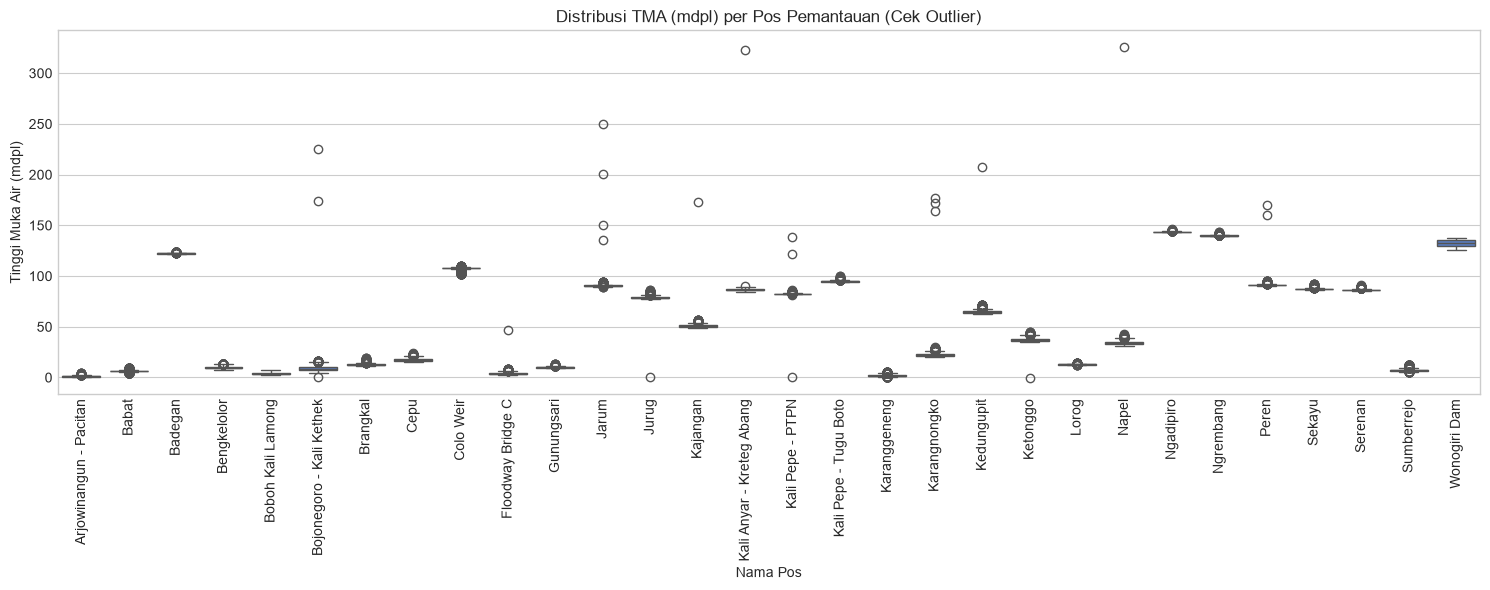

In [182]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train_df, x='nama_pos', y='tma_mdpl')
plt.xticks(rotation=90)
plt.title('Distribusi TMA (mdpl) per Pos Pemantauan (Cek Outlier)')
plt.ylabel('Tinggi Muka Air (mdpl)')
plt.xlabel('Nama Pos')
plt.tight_layout()
plt.show()

#### Insight Pencilan (Outlier Insight):
- **Observasi (Observation)**: Boxplot menunjukkan adanya pencilan bawah (lower outliers) yang cukup signifikan pada beberapa pos pemantauan (seperti Pacitan/Arjowinangun), sementara nilai atas menunjukkan distribusi yang memanjang ke atas (puncak banjir).
- **Tindakan (Action)**: Batas bawah akan dibatasi menggunakan formula `Q1 - 3.0 * IQR` untuk menyaring derau (noise) sensor, sedangkan nilai atas dibiarkan utuh.

### 2.2 Analisis Pola Deret Waktu (Time-Series Trend Analysis)

**Justifikasi & Tujuan (Justification & Objective):**
Mengidentifikasi komponen deret waktu seperti tren dan musiman, yang akan mendasari perancangan jendela statistik bergulir (rolling windows) dan lag autoregresif.

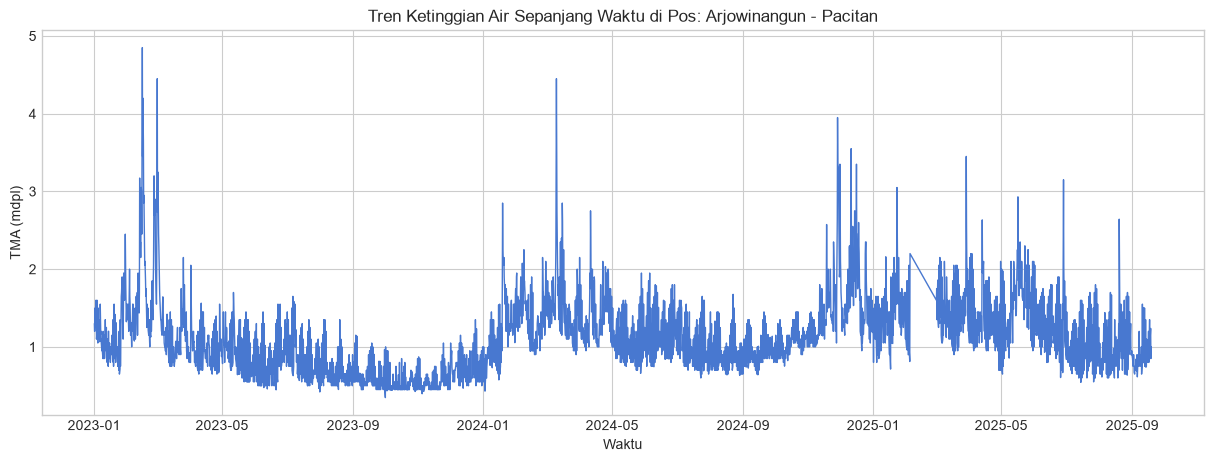

In [183]:
contoh_pos = train_df['nama_pos'].unique()[0]
data_contoh = train_df[train_df['nama_pos'] == contoh_pos]

plt.figure(figsize=(15, 5))
sns.lineplot(data=data_contoh, x='datetime', y='tma_mdpl', linewidth=1)
plt.title(f'Tren Ketinggian Air Sepanjang Waktu di Pos: {contoh_pos}')
plt.ylabel('TMA (mdpl)')
plt.xlabel('Waktu')
plt.show()

#### Insight Deret Waktu (Time-Series Insight):
- **Observasi (Observation)**: Ketinggian muka air menunjukkan pola musiman yang kuat (musim hujan vs musim kemarau) disertai fluktuasi jangka pendek yang cepat saat terjadi hujan.
- **Keputusan Pemodelan (Modeling Decision)**: Fitur lag autoregresif dan rata-rata historis sangat penting untuk memodelkan siklus musiman ini.

### 2.3 Analisis Data Hilang (Missing Value Analysis)

**Justifikasi & Tujuan (Justification & Objective):**
Mengidentifikasi letak dan volume data kosong pada data lingkungan untuk merancang strategi interpolasi tanpa kebocoran data.

In [184]:
missing_env = env_df.isnull().sum() / len(env_df) * 100
missing_env = missing_env[missing_env > 0].sort_values(ascending=False)

print("Persentase Data Hilang (Missing Values) pada Fitur Cuaca:")
print(missing_env)

Persentase Data Hilang (Missing Values) pada Fitur Cuaca:
nino_34                    1.458671
soil_moisture_0_7cm        0.081037
soil_moisture_28_100cm     0.081037
soil_moisture_7_28cm       0.081037
soil_moisture_100_255cm    0.081037
surface_pressure_hpa       0.081037
rmm1                       0.081037
pressure_msl_hpa           0.081037
rmm2                       0.081037
mjo_phase                  0.081037
mjo_amplitude              0.081037
mjo_active                 0.081037
dtype: float64


#### Insight Data Hilang (Missing Value Insight):
- **Observasi (Observation)**: Beberapa fitur lingkungan seperti kelembapan tanah (soil moisture) dan MJO memiliki persentase data hilang yang kecil.
- **Keputusan Pemodelan (Modeling Decision)**: Imputasi dilakukan per pos menggunakan interpolasi linier dengan batas tertentu untuk mencegah interpolasi garis lurus pada kekosongan panjang, diikuti oleh forward/backward fill.

### 2.4 Distribusi Variabel Target (TMA Distribution)

**Justifikasi & Tujuan (Justification & Objective):**
Memahami rentang dan bentuk sebaran data target TMA global sebelum digunakan untuk regresi.

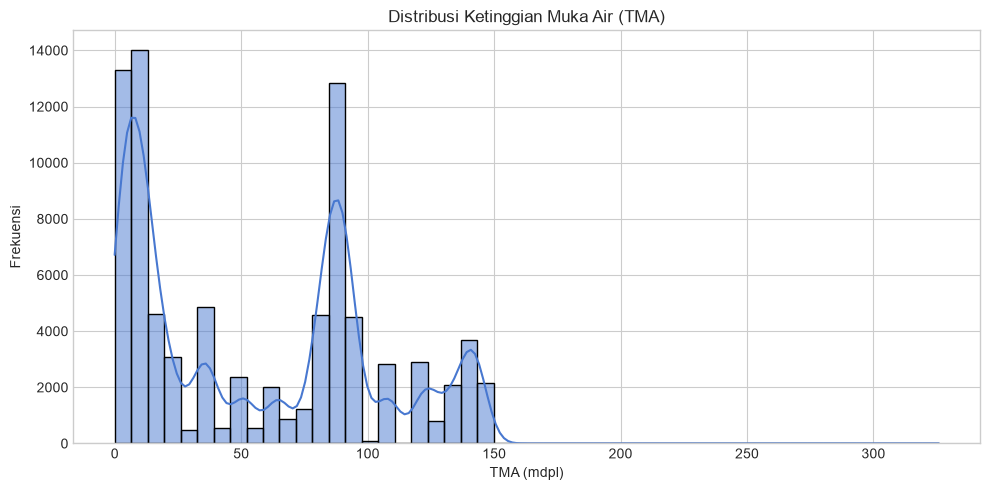

count    84396.000000
mean        56.482537
std         46.765914
min         -0.059668
25%         10.100000
50%         50.370000
75%         90.660938
max        325.830000
Name: tma_mdpl, dtype: float64


In [185]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['tma_mdpl'], kde=True, bins=50)
plt.title('Distribusi Ketinggian Muka Air (TMA)')
plt.xlabel('TMA (mdpl)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(train_df['tma_mdpl'].describe())

### 2.5 Perbandingan Frekuensi Sampling (Sampling Frequency Comparison)

**Justifikasi & Tujuan (Justification & Objective):**
Membandingkan resolusi temporal data TMA (misal 3 kali sehari) dengan data lingkungan (tiap jam) untuk penyelarasan timestamp yang tepat saat feature engineering.

In [186]:
print("Frekuensi sampling train_df (median selisih waktu per pos):")
sampling_train = train_df.sort_values(['nama_pos', 'datetime']).groupby('nama_pos')['datetime'].diff().median()
print(sampling_train)

print("\nFrekuensi sampling env_df (median selisih waktu per pos):")
sampling_env = env_df.sort_values(['nama_pos', 'datetime']).groupby('nama_pos')['datetime'].diff().median()
print(sampling_env)

Frekuensi sampling train_df (median selisih waktu per pos):
0 days 06:00:00

Frekuensi sampling env_df (median selisih waktu per pos):
0 days 01:00:00


### 2.6 Korelasi Fitur terhadap TMA (Feature Correlation with TMA)

**Justifikasi & Tujuan (Justification & Objective):**
Mengukur hubungan linier antara fitur lingkungan dengan target TMA untuk memandu rekayasa fitur interaksi.

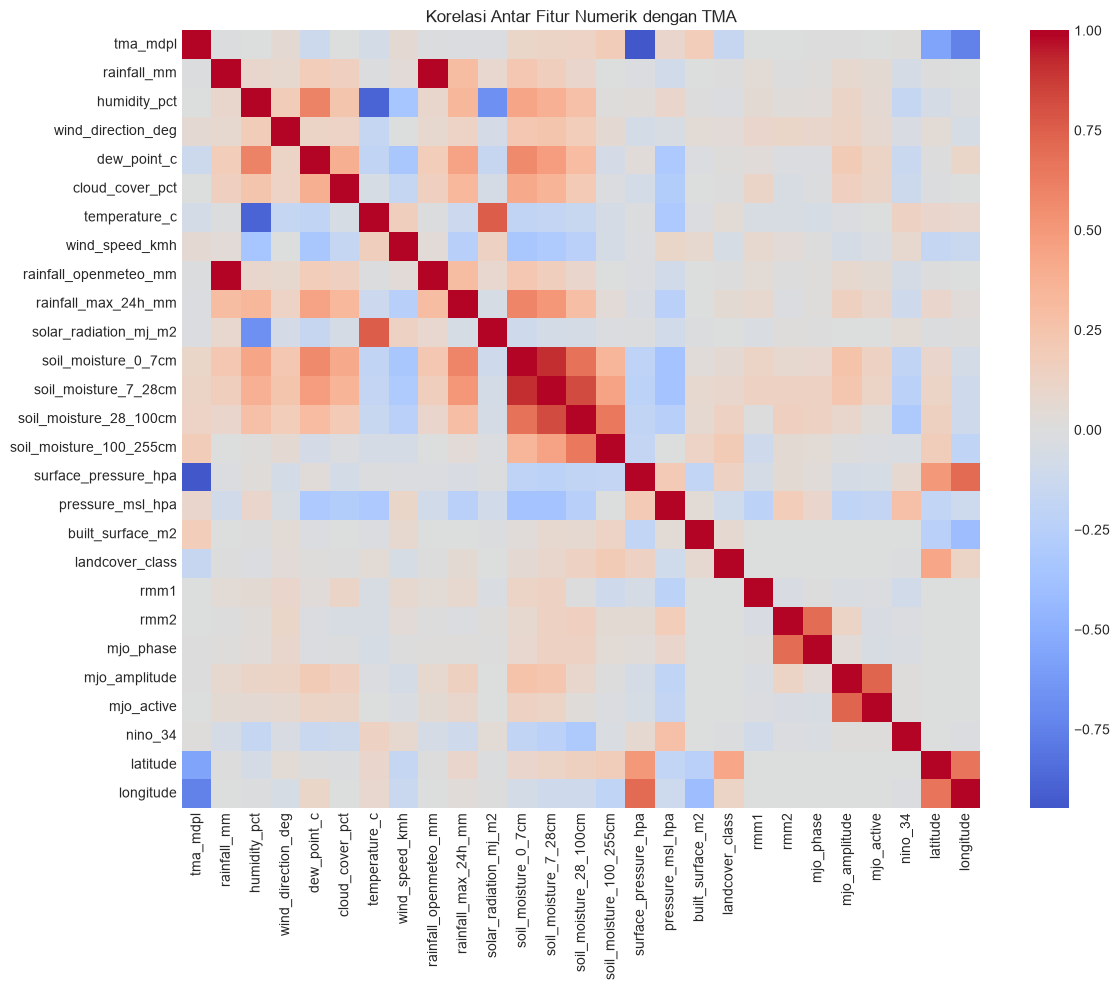

Korelasi setiap fitur terhadap TMA (diurutkan):
tma_mdpl                   1.000000
soil_moisture_100_255cm    0.189417
built_surface_m2           0.179301
soil_moisture_28_100cm     0.126973
soil_moisture_7_28cm       0.123752
soil_moisture_0_7cm        0.105786
pressure_msl_hpa           0.097006
wind_direction_deg         0.063566
wind_speed_kmh             0.057337
nino_34                    0.017774
mjo_amplitude              0.004439
mjo_phase                  0.003894
rmm2                       0.002720
mjo_active                 0.000827
humidity_pct               0.000426
cloud_cover_pct            0.000275
rmm1                      -0.002537
rainfall_openmeteo_mm     -0.005299
rainfall_mm               -0.005299
solar_radiation_mj_m2     -0.013010
rainfall_max_24h_mm       -0.025054
temperature_c             -0.076961
dew_point_c               -0.121663
landcover_class           -0.157293
latitude                  -0.565027
longitude                 -0.747092
surface_pressure

In [187]:
eda_merged = pd.merge(train_df, env_df, on=['nama_pos', 'datetime'], how='inner')

numeric_cols = eda_merged.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 10))
corr = eda_merged[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Korelasi Antar Fitur Numerik dengan TMA')
plt.tight_layout()
plt.show()

print("Korelasi setiap fitur terhadap TMA (diurutkan):")
print(corr['tma_mdpl'].sort_values(ascending=False))

### 2.7 Autokorelasi (ACF) & Autokorelasi Parsial (PACF)

**Justifikasi & Tujuan (Justification & Objective):**
Menghitung ketergantungan deret waktu terhadap masa lalunya untuk menentukan jumlah lag minimum yang optimal.

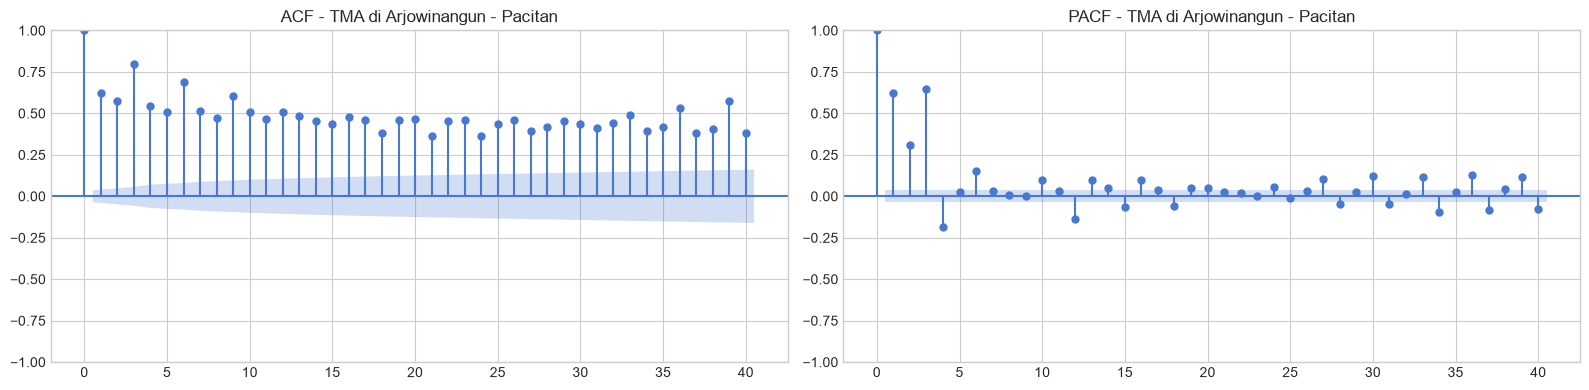

In [188]:
series_contoh = train_df[train_df['nama_pos'] == contoh_pos].sort_values('datetime')['tma_mdpl'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series_contoh, lags=40, ax=axes[0])
axes[0].set_title(f'ACF - TMA di {contoh_pos}')
plot_pacf(series_contoh, lags=40, ax=axes[1])
axes[1].set_title(f'PACF - TMA di {contoh_pos}')
plt.tight_layout()
plt.show()

### 2.8 Distribusi Fitur Kategorikal (Categorical Feature Distribution)

**Justifikasi & Tujuan (Justification & Objective):**
Memeriksa sebaran kelas pada fitur kategori untuk menentukan penanganan representasi nilainya.

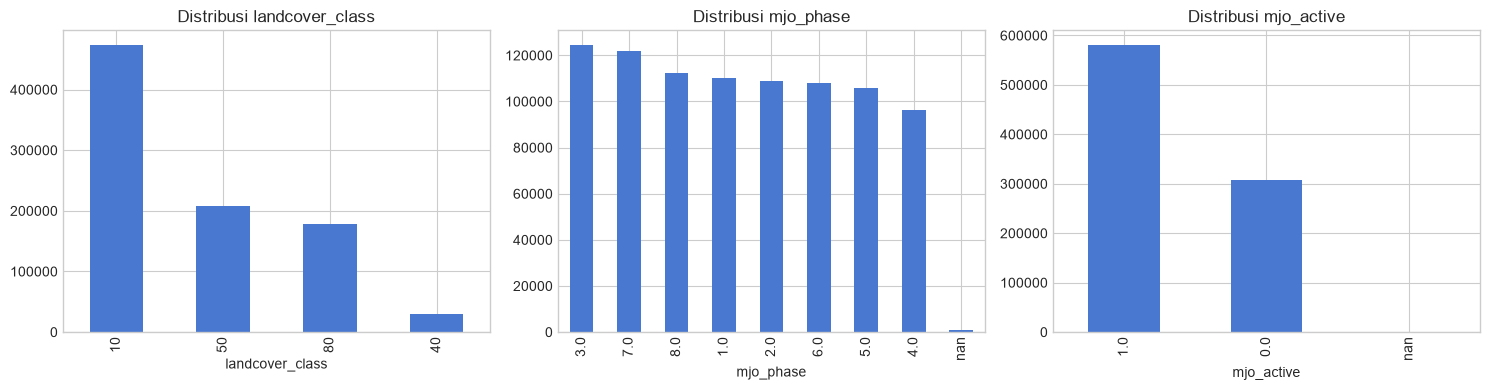

In [189]:
kolom_kategorikal_check = [c for c in ['landcover_class', 'mjo_phase', 'mjo_active'] if c in env_df.columns]

fig, axes = plt.subplots(1, len(kolom_kategorikal_check), figsize=(5 * len(kolom_kategorikal_check), 4))
if len(kolom_kategorikal_check) == 1:
    axes = [axes]
for ax, col in zip(axes, kolom_kategorikal_check):
    env_df[col].value_counts(dropna=False).plot(kind='bar', ax=ax)
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### 2.9 Peta Data Duplikat & Data Hilang (Duplicate & Missing Value Mapping)

**Justifikasi & Tujuan (Justification & Objective):**
Memastikan tidak ada duplikat kombinasi pos dan waktu yang merusak validasi, serta memvisualisasikan pola kekosongan data.

Jumlah baris duplikat (nama_pos, datetime) di train_df: 0
Jumlah baris duplikat (nama_pos, datetime) di env_df  : 0


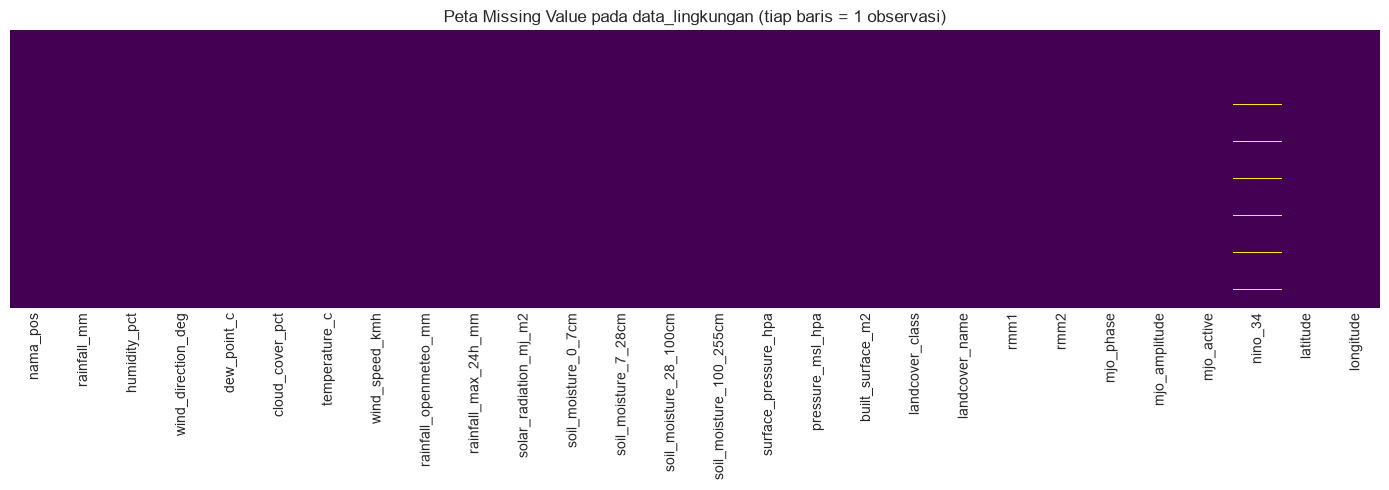

In [190]:
dup_train = train_df.duplicated(subset=['nama_pos', 'datetime']).sum()
dup_env = env_df.duplicated(subset=['nama_pos', 'datetime']).sum()
print(f"Jumlah baris duplikat (nama_pos, datetime) di train_df: {dup_train}")
print(f"Jumlah baris duplikat (nama_pos, datetime) di env_df  : {dup_env}")

plt.figure(figsize=(14, 5))
sns.heatmap(env_df.drop(columns=['datetime']).isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Peta Missing Value pada data_lingkungan (tiap baris = 1 observasi)')
plt.tight_layout()
plt.show()

## 3. Pembersihan & Pra-pemrosesan Data (Data Cleaning & Preprocessing)

### 3.1 Capping Pencilan dengan Metode IQR (Outlier Handling via IQR Capping)

**Justifikasi (Justification):**
Nilai TMA ekstrim bawah di bawah `Q1 - 3.0 * IQR` dibatasi (clipped) per pos pemantauan untuk menghilangkan pembacaan sensor yang salah (eror) tanpa mempengaruhi nilai tinggi (banjir) yang penting bagi model.

In [191]:
def cap_lower_iqr(series, multiplier=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (multiplier * IQR)
    return series.clip(lower=lower_bound)

print(">>> Before Capping Outlier (nilai TERTINGGI per pos, TIDAK disentuh)")
print(train_df.groupby("nama_pos")["tma_mdpl"].max().sort_values(ascending=False).head(5))

# Batasi pencilan bawah target TMA per stasiun
train_df["tma_mdpl"] = (
    train_df.groupby("nama_pos")["tma_mdpl"]
    .transform(cap_lower_iqr)
)

print("\nAfter Capping Outlier (nilai TERENDAH per pos)")
print(train_df.groupby("nama_pos")["tma_mdpl"].min().sort_values().head(5))

>>> Before Capping Outlier (nilai TERTINGGI per pos, TIDAK disentuh)
nama_pos
Napel                        325.830000
Kali Anyar - Kreteg Abang    323.207409
Jarum                        250.140000
Bojonegoro - Kali Kethek     225.130000
Kedungupit                   207.736480
Name: tma_mdpl, dtype: float64

After Capping Outlier (nilai TERENDAH per pos)
nama_pos
Bojonegoro - Kali Kethek    0.000000
Karanggeneng                0.000000
Arjowinangun - Pacitan      0.347639
Floodway Bridge C           2.039797
Boboh Kali Lamong           2.100000
Name: tma_mdpl, dtype: float64


### 3.2 Penghapusan Duplikat & Imputasi Data Hilang (Duplicate Removal & Missing Value Imputation)

**Justifikasi (Justification):**
1. **Penghapusan Duplikat**: Baris dengan stasiun dan waktu yang sama dihapus untuk mencegah kebocoran data.
2. **Interpolasi Linier (Limit=6)**: Mengisi kekosongan fitur kontinu. Pembatasan rentang hingga 6 jam dilakukan agar tidak membuat garis lurus pada kekosongan sensor yang lama (outage).
3. **ffill/bfill**: Mengisi variabel diskrit berdasarkan data terakhir yang diketahui.

In [192]:
def drop_pos_datetime_duplicates(df):
    return df.drop_duplicates(subset=['nama_pos', 'datetime']).reset_index(drop=True)

# 1. Hapus duplikat
train_df = drop_pos_datetime_duplicates(train_df)
env_df = drop_pos_datetime_duplicates(env_df)
test_df = drop_pos_datetime_duplicates(test_df)

# 2. Urutkan secara kronologis per stasiun
train_df = train_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
env_df = env_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
test_df = test_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)

print('Jumlah baris kosong sebelum imputasi:')
print(env_df.isnull().sum()[env_df.isnull().sum() > 0])

# 3. Imputasi fitur lingkungan diskrit menggunakan forward fill & backward fill
kolom_diskrit = ['mjo_phase', 'mjo_active', 'landcover_class', 'nino_34']
for col in kolom_diskrit:
    if col in env_df.columns:
        env_df[col] = env_df.groupby('nama_pos')[col].transform(lambda x: x.ffill().bfill())

# 4. Imputasi fitur kontinu dengan interpolasi linier (maksimal rentang 6 jam)
kolom_kontinu = [
    c for c in env_df.columns 
    if c not in kolom_diskrit and c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']
]
for col in kolom_kontinu:
    env_df[col] = env_df.groupby('nama_pos')[col].transform(
        lambda x: x.interpolate(method='linear', limit=6, limit_direction='both')
    )

# 5. Isi sisa nilai kosong di tepi dengan ffill lalu bfill
for col in kolom_kontinu:
    env_df[col] = env_df.groupby('nama_pos')[col].transform(lambda x: x.ffill().bfill())

print('\nJumlah baris kosong setelah imputasi:', env_df.isnull().sum().sum())

Jumlah baris kosong sebelum imputasi:
soil_moisture_0_7cm          720
soil_moisture_7_28cm         720
soil_moisture_28_100cm       720
soil_moisture_100_255cm      720
surface_pressure_hpa         720
pressure_msl_hpa             720
rmm1                         720
rmm2                         720
mjo_phase                    720
mjo_amplitude                720
mjo_active                   720
nino_34                    12960
dtype: int64

Jumlah baris kosong setelah imputasi: 0


### 3.3 Fitur Spasial: Koordinat & Metrik Jarak (Spatial Coordinate Features)

**Justifikasi (Justification):**
Jarak ke stasiun terdekat (Nearest Neighbor) dan ke pusat stasiun (Centroid) dihitung dengan rumus Haversine untuk membantu model mempelajari pola spasial dan kerapatan geografis stasiun.

### 3.3 Pengisian Baris Phantom (Phantom Row Fill)

**Justifikasi (Justification):**  
Mengisi celah waktu yang hilang pada data TMA agar fitur lag tidak merujuk ke periode yang salah. Gap di Feb 2025 menyebabkan `tma_lag_step1` merujuk ke data hari-hari sebelumnya, bukan 6 jam sebelumnya.


In [193]:
# Bangun grid lengkap per pos (jam 6, 12, 18) agar tidak ada gap waktu
grids = []
for pos, g in train_df.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6, 12, 18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid_train = pd.concat(grids, ignore_index=True)

# Merge: baris yang tidak ada di data asli = phantom row
train_df = grid_train.merge(train_df, on=['nama_pos', 'datetime'], how='left')
train_df = train_df.sort_values(['nama_pos', 'datetime'])
train_df['is_phantom'] = train_df['tma_mdpl'].isna().astype(int)
n_phantom = train_df['is_phantom'].sum()
print(f'Jumlah phantom row ditemukan: {n_phantom}')

# Interpolasi linear maks 4 steps (24 jam) untuk gap pendek
train_df['tma_mdpl'] = train_df.groupby('nama_pos')['tma_mdpl'].transform(
    lambda x: x.interpolate(method='linear', limit=4)
)

# Hapus phantom rows yang masih NaN (gap > 24 jam, tidak ter-interpolasi)
train_df = train_df[train_df['is_phantom'] == 0].drop(columns=['is_phantom']).reset_index(drop=True)
print(f'Setelah phantom fill: train_df shape = {train_df.shape}')


Jumlah phantom row ditemukan: 3112
Setelah phantom fill: train_df shape = (84396, 3)


In [194]:
coords = koordinat_df[['nama_pos', 'latitude', 'longitude']].drop_duplicates().copy()
coords = coords.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

coords_xy = coords.set_index('nama_pos')[['latitude', 'longitude']]
station_centroid_lat = coords_xy['latitude'].mean()
station_centroid_lon = coords_xy['longitude'].mean()

nearest_station_dist_km = {}
station_centroid_dist_km = {}

# Perhitungan jarak menggunakan formula Haversine
for pos in coords_xy.index:
    lat1 = coords_xy.loc[pos, 'latitude']
    lon1 = coords_xy.loc[pos, 'longitude']
    other = coords_xy.drop(index=pos, errors='ignore')

    if other.empty:
        nearest_station_dist_km[pos] = np.nan
    else:
        dlat = np.radians(other['latitude'].values - lat1)
        dlon = np.radians(other['longitude'].values - lon1)
        a = (
            np.sin(dlat / 2) ** 2 
            + np.cos(np.radians(lat1)) * np.cos(np.radians(other['latitude'].values)) * np.sin(dlon / 2) ** 2
        )
        dist = 2 * 6371 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        nearest_station_dist_km[pos] = float(np.min(dist))

    # Jarak ke centroid
    dlat_c = np.radians(station_centroid_lat - lat1)
    dlon_c = np.radians(station_centroid_lon - lon1)
    a_c = (
        np.sin(dlat_c / 2) ** 2 
        + np.cos(np.radians(lat1)) * np.cos(np.radians(station_centroid_lat)) * np.sin(dlon_c / 2) ** 2
    )
    station_centroid_dist_km[pos] = float(2 * 6371 * np.arctan2(np.sqrt(a_c), np.sqrt(1 - a_c)))

# Gabungkan fitur koordinat dan jarak ke dalam dataset
train_df = train_df.merge(coords, on='nama_pos', how='left')
test_df = test_df.merge(coords, on='nama_pos', how='left')
train_df['nearest_station_dist_km'] = train_df['nama_pos'].map(nearest_station_dist_km)
test_df['nearest_station_dist_km'] = test_df['nama_pos'].map(nearest_station_dist_km)
train_df['station_centroid_dist_km'] = train_df['nama_pos'].map(station_centroid_dist_km)
test_df['station_centroid_dist_km'] = test_df['nama_pos'].map(station_centroid_dist_km)

print('Fitur spasial stasiun ditambahkan: latitude, longitude, nearest_station_dist_km, station_centroid_dist_km')

Fitur spasial stasiun ditambahkan: latitude, longitude, nearest_station_dist_km, station_centroid_dist_km


## 4. Rekayasa Fitur (Feature Engineering)

Rekayasa fitur bertujuan untuk mengekstrak fitur temporal, meteorologis, dan hidrologis untuk pemodelan regresi tabular. Kita membuat lag, statistik bergulir, indeks fisik hidrologi, dan hubungan sungai (HydroRIVERS).

In [195]:
print('Memulai Feature Engineering...')

train_df = train_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
env_df = env_df.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)

print('Data telah diurutkan dengan benar.')

Memulai Feature Engineering...
Data telah diurutkan dengan benar.


### 4.1 Fitur Lag TMA (TMA Lag Features)

**Justifikasi (Justification):**
TMA memiliki ketergantungan diri yang sangat kuat. Kita membuat lag `[3, 6, 9, 12, 21]` (dalam langkah observasi). Lag 1 dan 2 dilewati karena pada set pengujian terdapat celah waktu (gap) sehingga kita harus memprediksi langkah ke depan tanpa bergantung pada lag terdekat.

In [196]:
LAG_STEPS = [1,2, 3, 6, 9, 12, 21, 28]
g_tma = train_df.groupby('nama_pos')['tma_mdpl']
for step in LAG_STEPS:
    train_df[f'tma_lag_step{step}'] = g_tma.shift(step)

print(f'Fitur Lag TMA selesai. Total kolom train_df saat ini: {train_df.shape[1]}')

Fitur Lag TMA selesai. Total kolom train_df saat ini: 15


### 4.2 Fitur Lag Curah Hujan (Rainfall Lag Features)

**Justifikasi (Justification):**
Air hujan membutuhkan waktu untuk mengalir di atas tanah hingga masuk ke saluran sungai (runoff delay). Lag curah hujan `[1, 3, 6, 12, 24]` jam merepresentasikan penundaan waktu respons daerah aliran sungai (DAS).

In [197]:
lag_hours_env = [1, 3, 6, 12, 24]

for lag in lag_hours_env:
    env_df[f'rainfall_lag_{lag}h'] = env_df.groupby('nama_pos')['rainfall_mm'].shift(lag)

print(f'Fitur Lag Rainfall selesai. Total kolom env_df saat ini: {env_df.shape[1]}')

Fitur Lag Rainfall selesai. Total kolom env_df saat ini: 34


### 4.3 Fitur Statistik Bergulir TMA (TMA Rolling Features)

**Justifikasi (Justification):**
Nilai rata-rata, maksimum, dan minimum bergulir dari TMA sebelumnya (menggunakan shift 1 untuk mencegah kebocoran data) menangkap tren jangka pendek hingga menengah.

In [198]:
ROLL_WINDOWS = [3, 9, 21] 

# Perhitungan rolling pada TMA yang di-shift untuk mencegah kebocoran data target
shifted_tma = train_df.groupby('nama_pos')['tma_mdpl'].shift(1)
for w in ROLL_WINDOWS:
    train_df[f'tma_rollmean_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).mean())
    train_df[f'tma_rollmax_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).max())
    train_df[f'tma_rollmin_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=1).min())
    train_df[f'tma_rollstd_{w}'] = shifted_tma.groupby(train_df['nama_pos']).transform(lambda x: x.rolling(w, min_periods=2).std().fillna(0))

print(f'Fitur Rolling TMA selesai. Total kolom train_df saat ini: {train_df.shape[1]}')

Fitur Rolling TMA selesai. Total kolom train_df saat ini: 27


### 4.4 Statistik Bergulir Curah Hujan & Kelembapan Tanah (Rainfall & Soil Moisture Rolling)

**Justifikasi (Justification):**
Akumulasi hujan (3 jam hingga 7 hari) mewakili volume air yang masuk ke DAS, sedangkan nilai maksimum bergulir menangkap intensitas hujan. Rata-rata kelembapan tanah menangkap tingkat kejenuhan tanah.

In [199]:
rolling_windows = [3, 6, 12, 24, 48, 72, 168]

for w in rolling_windows:
    env_df[f'rainfall_sum_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).sum()
    )
    env_df[f'rainfall_max_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).max()
    )
    if 'soil_moisture_0_7cm' in env_df.columns:
        env_df[f'soil_moisture_0_7_mean_{w}h'] = env_df.groupby('nama_pos')['soil_moisture_0_7cm'].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )

print(f'Fitur Rolling env selesai. Total kolom env_df saat ini: {env_df.shape[1]}')

Fitur Rolling env selesai. Total kolom env_df saat ini: 55


### 4.5 Deviasi Standar Bergulir Curah Hujan (Rainfall Rolling Std)

**Justifikasi (Justification):**
Mengukur volatilitas dan perubahan intensitas curah hujan bergulir yang sering memicu perubahan debit air secara mendadak.

In [200]:
for w in [6, 24]:
    env_df[f'rainfall_std_{w}h'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(window=w, min_periods=1).std()
    )

env_df[[f'rainfall_std_{w}h' for w in [6, 24]]] = env_df[[f'rainfall_std_{w}h' for w in [6, 24]]].fillna(0)

print('Selesai.')

Selesai.


### 4.6 Indeks Akumulasi Hujan (Antecedent Precipitation Index - API)

**Justifikasi (Justification):**
API memperkirakan kejenuhan tanah berdasarkan asumsi bahwa kelembapan tanah bertambah karena hujan namun menyusut secara eksponensial seiring waktu berjalan:
$$API_t = P_t + k \times API_{t-1}$$
Konstanta peluruhan ($k$) diatur 0.9 per hari, lalu diskalakan secara hourly ($0.9^{1/24}$).

In [201]:
def compute_api(rain_values, k):
    api = np.zeros(len(rain_values))
    for i in range(len(rain_values)):
        prev = api[i - 1] if i > 0 else 0.0
        api[i] = rain_values[i] + k * prev
    return api

k_per_hari = 0.9
k_per_jam = k_per_hari ** (1 / 24)

env_df = env_df.sort_values(['nama_pos', 'datetime'])
env_df['api'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(
    lambda s: compute_api(s.values, k_per_jam)
)
print('Fitur API selesai ditambahkan.')

Fitur API selesai ditambahkan.


### 4.7 Fitur Interaksi: Indeks Kejenuhan (Saturation Index)

**Justifikasi (Justification):**
Efek hujan terhadap kenaikan TMA bersifat non-linier. Hujan lebat pada tanah kering menghasilkan limpasan kecil, sedangkan hujan kecil pada tanah yang sudah jenuh air dapat memicu kenaikan TMA yang drastis. Indeks ini dibuat dari perkalian akumulasi hujan 24 jam dengan rata-rata kelembapan tanah.

In [202]:
if 'soil_moisture_0_7_mean_24h' in env_df.columns:
    env_df['saturation_index'] = env_df['rainfall_sum_24h'] * env_df['soil_moisture_0_7_mean_24h']
    print("Fitur 'saturation_index' berhasil dibuat.")
else:
    print('Kolom soil_moisture_0_7_mean_24h tidak ditemukan, fitur ini dilewati.')

Fitur 'saturation_index' berhasil dibuat.


### 4.8 Waktu Sejak Hujan Terakhir (Hours Since Last Rain)

**Justifikasi (Justification):**
Menunjukkan durasi keringnya wilayah tangkapan air. Nilai yang kecil menunjukkan tanah masih basah dan peka terhadap curah hujan baru.

In [203]:
def hitung_jam_sejak_hujan(rainfall_series, threshold=1.0):
    is_rain = (rainfall_series > threshold)
    reset_groups = is_rain.cumsum()
    jam_sejak = is_rain.groupby(reset_groups).cumcount()
    jam_sejak = jam_sejak.where(reset_groups > 0, np.nan)
    return jam_sejak

env_df['hours_since_rain'] = env_df.groupby('nama_pos')['rainfall_mm'].transform(hitung_jam_sejak_hujan)
env_df['hours_since_rain'] = env_df['hours_since_rain'].fillna(9999)  # Sebelum hujan pertama = sudah lama tidak hujan
print('Selesai.')

Selesai.


### 4.9 Rata-rata Curah Hujan Wilayah Tetangga (Spatial Neighbor Mean Rainfall)

**Justifikasi (Justification):**
Menggunakan rata-rata curah hujan dari K stasiun terdekat untuk menghasilkan fitur hujan regional guna mengatasi keterbatasan pencatatan lokal.

In [204]:
K_NEIGHBORS = 2
coords = koordinat_df.set_index('nama_pos')[['latitude', 'longitude']] if 'latitude' in koordinat_df.columns else None

if coords is not None:
    neighbor_map = {}
    for pos in daftar_pos:
        if pos not in coords.index:
            neighbor_map[pos] = []
            continue
        # Jarak kuadrat koordinat
        dists = ((coords['latitude'] - coords.loc[pos, 'latitude'])**2 + (coords['longitude'] - coords.loc[pos, 'longitude'])**2)
        dists = dists.drop(index=pos, errors='ignore').sort_values()
        neighbor_map[pos] = dists.index[:K_NEIGHBORS].tolist()

    # Ekstraksi rata-rata curah hujan stasiun terdekat
    rainfall_wide = env_df.pivot(index='datetime', columns='nama_pos', values='rainfall_mm')
    neighbor_rain = {}
    for pos in daftar_pos:
        neigh = neighbor_map.get(pos, [])
        neighbor_rain[pos] = rainfall_wide[neigh].mean(axis=1) if neigh else pd.Series(np.nan, index=rainfall_wide.index)
    neighbor_rain_df = (
        pd.DataFrame(neighbor_rain).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='rainfall_neighbor_mean')
    )
    env_df = env_df.merge(neighbor_rain_df, on=['nama_pos', 'datetime'], how='left')
    print('Fitur rainfall_neighbor_mean ditambahkan.')
else:
    print('Kolom lat/lon tidak ditemukan — cek nama kolom di koordinat_pos.csv. Fitur dilewati.')

Fitur rainfall_neighbor_mean ditambahkan.


### 4.10 Penyelarasan Jaringan Sungai & Fitur Hulu (Snap to River & Upstream Features)

**Justifikasi (Justification):**
Air mengalir dari hulu ke hilir. Kenaikan TMA di pos hilir sangat dipengaruhi oleh TMA dan curah hujan di pos hulu. 
1. **Penyelarasan Sungai (River Snapping)**: Menggunakan Geopandas, koordinat pos diselaraskan ke ruas sungai terdekat pada database HydroRIVERS.
2. **Identifikasi Hulu (Upstream Identification)**: Memetakan stasiun hulu yang berada pada sungai yang sama (`MAIN_RIV`) dengan jarak hilir (`DIST_DN_KM`) lebih jauh.
3. **Fitur Hulu (Upstream Features)**: Menghitung rata-rata curah hujan dan TMA dari stasiun hulu tersebut sebagai proksi debit air kiriman hulu.

In [205]:
import geopandas as gpd
from shapely.geometry import Point

if 'upstream_rainfall_mean' in env_df.columns and 'upstream_tma_mean' in train_df.columns:
    print('Fitur upstream sudah ada, dilewati.')
else:
    gdf_rivers = gpd.read_file('sebelas-maret-statistics-data-science-2026/data_pendukung/HydroRIVERS_v10_au_shp')

    # Snap stasiun pemantauan ke ruas sungai terdekat
    gdf_pos = gpd.GeoDataFrame(
        koordinat_df.copy(),
        geometry=[Point(xy) for xy in zip(koordinat_df['longitude'], koordinat_df['latitude'])],
        crs='EPSG:4326'
    )
    if gdf_rivers.crs != gdf_pos.crs:
        gdf_rivers = gdf_rivers.to_crs(gdf_pos.crs)

    gdf_pos_snapped = gpd.sjoin_nearest(
        gdf_pos, gdf_rivers[['HYRIV_ID', 'MAIN_RIV', 'DIST_DN_KM', 'DIS_AV_CMS', 'geometry']],
        how='left', distance_col='snap_dist_deg'
    )
    gdf_pos_snapped = gdf_pos_snapped.drop_duplicates(subset='nama_pos')

    print('Contoh hasil snapping pos ke ruas sungai:')
    display(gdf_pos_snapped[['nama_pos', 'MAIN_RIV', 'DIST_DN_KM', 'snap_dist_deg']].head(10))

    print('\nDistribusi jarak snapping (derajat, makin kecil makin dekat):')
    print(gdf_pos_snapped['snap_dist_deg'].describe())

    pos_river_info = gdf_pos_snapped.set_index('nama_pos')[['MAIN_RIV', 'DIST_DN_KM']]

    # Cari stasiun hulu pada sungai utama yang sama
    K_UPSTREAM = 2
    upstream_map = {}
    for pos in daftar_pos:
        if pos not in pos_river_info.index:
            upstream_map[pos] = []
            continue
        main_riv_pos = pos_river_info.loc[pos, 'MAIN_RIV']
        dist_dn_pos = pos_river_info.loc[pos, 'DIST_DN_KM']

        kandidat = pos_river_info[
            (pos_river_info['MAIN_RIV'] == main_riv_pos) &
            (pos_river_info['DIST_DN_KM'] > dist_dn_pos) &
            (pos_river_info.index != pos)
        ].sort_values('DIST_DN_KM')

        upstream_map[pos] = kandidat.index[:K_UPSTREAM].tolist()

    print('\nContoh pemetaan upstream (pos -> pos upstream terdekat):')
    for pos in daftar_pos[:5]:
        print(f'  {pos}: {upstream_map[pos]}')

    # Rata-rata curah hujan stasiun hulu
    rainfall_wide_riv = env_df.pivot(index='datetime', columns='nama_pos', values='rainfall_mm')
    upstream_rain = {}
    for pos in daftar_pos:
        up = upstream_map.get(pos, [])
        upstream_rain[pos] = rainfall_wide_riv[up].mean(axis=1) if up else pd.Series(np.nan, index=rainfall_wide_riv.index)
    upstream_rain_df = (
        pd.DataFrame(upstream_rain).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='upstream_rainfall_mean')
    )
    env_df = env_df.merge(upstream_rain_df, on=['nama_pos', 'datetime'], how='left')

    tma_wide_riv = train_df.pivot(index='datetime', columns='nama_pos', values='tma_mdpl')
    upstream_tma = {}
    for pos in daftar_pos:
        up = upstream_map.get(pos, [])
        upstream_tma[pos] = tma_wide_riv[up].mean(axis=1) if up else pd.Series(np.nan, index=tma_wide_riv.index)
    upstream_tma_df = (
        pd.DataFrame(upstream_tma).reset_index()
        .melt(id_vars='datetime', var_name='nama_pos', value_name='upstream_tma_mean')
    )
    train_df = train_df.merge(upstream_tma_df, on=['nama_pos', 'datetime'], how='left')

    print('\nFitur upstream_rainfall_mean (env_df) dan upstream_tma_mean (train_df) berhasil ditambahkan.')

Contoh hasil snapping pos ke ruas sungai:


,nama_pos,MAIN_RIV,DIST_DN_KM,snap_dist_deg
0,Ketonggo,50387677,245.5,0.001183
1,Sekayu,50387677,303.7,0.004183
2,Cepu,50387677,194.2,0.000683
3,Karanggeneng,50387677,35.1,0.000047
4,Bojonegoro - Kali Kethek,50387677,134.7,0.001387
5,Badegan,50387677,315.8,0.000517
6,Lorog,50419937,9.3,0.001033
7,Wonogiri Dam,50387677,378.3,0.001593
8,Kajangan,50387677,271.6,0.001161
9,Boboh Kali Lamong,50392385,11.8,0.002483



Distribusi jarak snapping (derajat, makin kecil makin dekat):
count    30.000000
mean      0.002238
std       0.002973
min       0.000025
25%       0.000602
50%       0.001217
75%       0.001743
max       0.011183
Name: snap_dist_deg, dtype: float64

Contoh pemetaan upstream (pos -> pos upstream terdekat):
  Arjowinangun - Pacitan: ['Gunungsari']
  Babat: ['Sumberrejo', 'Bojonegoro - Kali Kethek']
  Badegan: ['Kali Anyar - Kreteg Abang', 'Jurug']
  Bengkelolor: []
  Boboh Kali Lamong: ['Bengkelolor']

Fitur upstream_rainfall_mean (env_df) dan upstream_tma_mean (train_df) berhasil ditambahkan.


### 4.11 Penyandian Waktu Siklik (Cyclical Time Encoding)

**Justifikasi (Justification):**
Waktu (jam, hari, bulan) bersifat siklik. Penyandian menggunakan fungsi sinus dan kosinus menjaga kontinuitas waktu sehingga jam 23 dianggap dekat dengan jam 0.

In [206]:
def add_cyclical(df):
    df = df.copy()
    hour = df['datetime'].dt.hour
    dow = df['datetime'].dt.dayofweek
    month = df['datetime'].dt.month
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)
    doy = df['datetime'].dt.dayofyear
    df['dayofyear_sin'] = np.sin(2 * np.pi * doy / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * doy / 365)
    df['musim_hujan'] = month.isin([11, 12, 1, 2, 3]).astype(int)
    return df

train_df = add_cyclical(train_df)
print('Cyclical Encoding selesai.')

Cyclical Encoding selesai.


### 4.12 Penggabungan Akhir Dataset Fitur (Final Feature Merging)

**Justifikasi (Justification):**
Menggabungkan seluruh fitur TMA dan lingkungan menjadi satu matriks data latih final (`train_full`).

In [207]:
env_feature_cols = [
    c for c in env_df.columns 
    if c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']
]

train_full = train_df.merge(
    env_df[['nama_pos', 'datetime'] + env_feature_cols], 
    on=['nama_pos', 'datetime'], 
    how='left'
)
train_max_date = train_full['datetime'].max()

print('Bentuk train_full:', train_full.shape)
train_full.head()

Bentuk train_full: (84396, 94)


,nama_pos,datetime,tma_mdpl,latitude,longitude,nearest_station_dist_km,station_centroid_dist_km,tma_lag_step1,tma_lag_step2,tma_lag_step3,...,rainfall_sum_168h,rainfall_max_168h,soil_moisture_0_7_mean_168h,rainfall_std_6h,rainfall_std_24h,api,saturation_index,hours_since_rain,rainfall_neighbor_mean,upstream_rainfall_mean
0,Arjowinangun - Pacitan,2023-01-01 06:00:00,1.30,-8.197561,111.114314,7.188337,80.392474,NaN,NaN,NaN,...,0.0,0.0,0.407000,0.000000,0.000000,0.000000,0.000000,9999.0,0.00,0.0
1,Arjowinangun - Pacitan,2023-01-01 12:00:00,1.20,-8.197561,111.114314,7.188337,80.392474,1.30,NaN,NaN,...,0.7,0.4,0.398154,0.160208,0.119829,0.698250,0.278708,9999.0,0.35,0.4
2,Arjowinangun - Pacitan,2023-01-01 18:00:00,1.50,-8.197561,111.114314,7.188337,80.392474,1.20,1.3,NaN,...,4.1,1.7,0.399000,0.625033,0.421984,4.036537,1.635900,4.0,0.15,0.2
3,Arjowinangun - Pacitan,2023-01-02 06:00:00,1.45,-8.197561,111.114314,7.188337,80.392474,1.50,1.2,1.3,...,4.9,1.7,0.397065,0.040825,0.373560,4.601008,1.931417,16.0,0.05,0.0
4,Arjowinangun - Pacitan,2023-01-02 12:00:00,1.25,-8.197561,111.114314,7.188337,80.392474,1.45,1.5,1.2,...,6.7,1.7,0.396027,0.481664,0.427327,6.278335,2.369250,0.0,0.65,1.2


## 5. Konfigurasi Latih & Validasi Model (Model Training & Validation Setup)

Menentukan skema evaluasi dan pembagian data deret waktu untuk menghindari kebocoran data ke masa lalu, serta menghitung baseline rata-rata.

### 5.1 Pembagian Dataset (Dataset Splitting)

**Justifikasi (Justification):**
Data dibagi secara kronologis menjadi:
- **Validation Set (val_data)**: 60 hari terakhir sebagai proksi uji.
- **Early Stopping Set (es_data)**: 60 hari sebelum validasi untuk memantau overfit.
- **Training Set (train_data)**: Seluruh data sebelumnya.

In [208]:
print('Memulai Pemisahan Data (Splitting)...')

train_full_sorted = (
    train_full.dropna(subset=[f'tma_lag_step{max(LAG_STEPS)}'])
    .sort_values('datetime')
    .reset_index(drop=True)
)

val_window_days = 60
es_window_days = 60
score_cutoff_date = train_max_date - pd.Timedelta(days=val_window_days)
es_cutoff_date = train_max_date - pd.Timedelta(days=val_window_days + es_window_days)

train_data = train_full_sorted[train_full_sorted['datetime'] <= es_cutoff_date]
es_data = train_full_sorted[
    (train_full_sorted['datetime'] > es_cutoff_date) & (train_full_sorted['datetime'] <= score_cutoff_date)
]
val_data = train_full_sorted[train_full_sorted['datetime'] > score_cutoff_date]

print(f"train_data : {train_data.shape} | {train_data['datetime'].min()} -> {train_data['datetime'].max()}")
print(f"es_data    : {es_data.shape} | {es_data['datetime'].min()} -> {es_data['datetime'].max()}")
print(f"val_data   : {val_data.shape} | {val_data['datetime'].min()} -> {val_data['datetime'].max()}")

Memulai Pemisahan Data (Splitting)...
train_data : (72773, 94) | 2023-01-10 12:00:00 -> 2025-05-21 18:00:00
es_data    : (5399, 94) | 2025-05-22 06:00:00 -> 2025-07-20 18:00:00
val_data   : (5384, 94) | 2025-07-21 06:00:00 -> 2025-09-18 18:00:00


### 5.2 Rata-rata Historis & Nilai Dasar Stasiun (Station Baselines & Historical Means)

**Justifikasi (Justification):**
1. **Baseline Stasiun**: Menghitung baseline mean/min/max per pos karena stasiun berada di sungai dengan elevasi mutlak (mdpl) yang berbeda.
2. **Rata-rata Historis**: Rata-rata per jam per pos untuk menangkap pola pasang surut harian.

In [209]:
# Compute station baseline (keep min/max, drop mean or keep all as in original)
station_baseline = train_data.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean',
    station_min_tma='min',
    station_max_tma='max'
).reset_index()

# Mappings for recursive validation
station_mean_mapping = train_data.groupby('nama_pos')['tma_mdpl'].mean().to_dict()
station_min_mapping = train_data.groupby('nama_pos')['tma_mdpl'].min().to_dict()
station_max_mapping = train_data.groupby('nama_pos')['tma_mdpl'].max().to_dict()

train_data = train_data.merge(station_baseline, on='nama_pos', how='left')
es_data = es_data.merge(station_baseline, on='nama_pos', how='left')
val_data = val_data.merge(station_baseline, on='nama_pos', how='left')

hist_mean_map = train_data.assign(hour=train_data['datetime'].dt.hour).groupby(['nama_pos', 'hour'])['tma_mdpl'].mean()
hist_mean_map.name = 'tma_hist_mean_by_pos_hour'

def tambah_fitur_historis(df, hist_map):
    df = df.copy()
    df['hour_tmp'] = df['datetime'].dt.hour
    df = df.merge(hist_map, left_on=['nama_pos', 'hour_tmp'], right_index=True, how='left')
    return df.drop(columns=['hour_tmp'])

train_data = tambah_fitur_historis(train_data, hist_mean_map)
es_data = tambah_fitur_historis(es_data, hist_mean_map)
val_data = tambah_fitur_historis(val_data, hist_mean_map)

# Demean lag and rolling features in train_data, es_data, and val_data
features_to_demean = []
for step in LAG_STEPS:
    features_to_demean.append(f'tma_lag_step{step}')
for w in ROLL_WINDOWS:
    features_to_demean.append(f'tma_rollmean_{w}')
    features_to_demean.append(f'tma_rollmax_{w}')
    features_to_demean.append(f'tma_rollmin_{w}')

for col in features_to_demean:
    if col in train_data.columns:
        train_data[col] = train_data[col] - train_data['tma_hist_mean_by_pos_hour']
    if col in es_data.columns:
        es_data[col] = es_data[col] - es_data['tma_hist_mean_by_pos_hour']
    if col in val_data.columns:
        val_data[col] = val_data[col] - val_data['tma_hist_mean_by_pos_hour']

X_train = train_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_train = train_data['tma_mdpl']
X_es = es_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_es = es_data['tma_mdpl']
X_val = val_data.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
y_val = val_data['tma_mdpl']

print('Fitur historis dan baseline stasiun ditambahkan, lags & rolling features telah di-demean. Bentuk X_train sekarang:', X_train.shape)


Fitur historis dan baseline stasiun ditambahkan, lags & rolling features telah di-demean. Bentuk X_train sekarang: (72773, 96)


### 5.3 Validasi Silang Deret Waktu (Time-Series Cross-Validation)

**Justifikasi (Justification):**
Evaluasi stabilitas model menggunakan skema 3-fold walk-forward validation pada periode sejarah yang berbeda untuk memastikan keandalan model.

In [210]:
# N_FOLDS = 3
# fold_val_span_days = 45
# max_date_cv = train_full_sorted['datetime'].max()
# fold_scores = []
# 
# for k in range(N_FOLDS, 0, -1):
#     val_end = pd.Timestamp(max_date_cv) - pd.Timedelta(days=(k - 1) * fold_val_span_days)
#     val_start = val_end - pd.Timedelta(days=fold_val_span_days)
#     tr_mask = train_full_sorted['datetime'] <= val_start
#     va_mask = (train_full_sorted['datetime'] > val_start) & (train_full_sorted['datetime'] <= val_end)
#     if tr_mask.sum() < 50 or va_mask.sum() < 10:
#         print(f'Fold dilewati (data tidak cukup): {val_start.date()} - {val_end.date()}')
#         continue
#     tr_fold = tambah_fitur_historis(train_full_sorted[tr_mask], hist_mean_map)
#     va_fold = tambah_fitur_historis(train_full_sorted[va_mask], hist_mean_map)
#     Xtr = tr_fold.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
#     ytr = tr_fold['tma_mdpl']
#     Xva = va_fold.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
#     yva = va_fold['tma_mdpl']
#     
#     for col in ['nama_pos', 'landcover_class']:
#         if col in Xtr.columns:
#             cats = pd.concat([Xtr[col].astype(str), Xva[col].astype(str)]).unique()
#             Xtr[col] = pd.Categorical(Xtr[col].astype(str), categories=cats)
#             Xva[col] = pd.Categorical(Xva[col].astype(str), categories=cats)
#             
#     Xtr = Xtr.drop(columns=['landcover_name'], errors='ignore')
#     Xva = Xva.drop(columns=['landcover_name'], errors='ignore')
#     
#     m = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, objective='rmse', verbosity=-1)
#     m.fit(Xtr, ytr)
#     pred = m.predict(Xva)
#     rmse = math.sqrt(mean_squared_error(yva, pred))
#     fold_scores.append(rmse)
#     print(f'Fold val [{val_start.date()} - {val_end.date()}] RMSE: {rmse:.4f}')
# 
# print('\nRata-rata RMSE CV:', np.mean(fold_scores) if fold_scores else '-')
# print('Std RMSE CV      :', np.std(fold_scores) if fold_scores else '-')

### 5.4 Penyandian Variabel Kategorikal (Categorical Variable Encoding)

**Justifikasi (Justification):**
Mengubah kolom objek ke tipe Categorical agar dapat ditangani secara optimal oleh LightGBM/XGBoost.

In [211]:
for df_ in [X_train, X_es, X_val]:
    df_.drop(columns=['landcover_name'], errors='ignore', inplace=True)

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Kolom kategorikal terdeteksi: {cat_cols}')

for col in cat_cols:
    semua_kategori = pd.concat([
        X_train[col].astype(str),
        X_es[col].astype(str),
        X_val[col].astype(str)
    ]).unique()
    X_train[col] = pd.Categorical(X_train[col].astype(str), categories=semua_kategori)
    X_es[col] = pd.Categorical(X_es[col].astype(str), categories=semua_kategori)
    X_val[col] = pd.Categorical(X_val[col].astype(str), categories=semua_kategori)

print('Selesai.')

Kolom kategorikal terdeteksi: ['nama_pos']
Selesai.


## 6. Pelatihan & Evaluasi Model (Model Training & Evaluation)

Kami melatih tiga algoritma gradient boosting yang berbeda (LightGBM, XGBoost, dan CatBoost). Model-model ini dipilih karena kemampuannya yang sangat baik dalam menangani data tabular, menangkap hubungan non-linier, dan mendukung penanganan fitur kategorikal secara native. 

Secara krusial, kami mengevaluasi model menggunakan **Validasi Rekursif Walk-Forward (Recursive Walk-Forward Validation)** untuk mengukur akumulasi kesalahan prediksi pada horizon peramalan.

### 6.1 Model LightGBM Regressor

**Justifikasi (Justification):**
LightGBM tumbuh secara leaf-wise, sangat cepat dan efisien pada data tabular besar.

In [212]:
LR = 0.05

# model_lgbm = LGBMRegressor(n_estimators=1500, learning_rate=LR, random_state=42, objective='rmse', max_depth=6, reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)

# model_lgbm.fit(
#     X_train, y_train,
#     eval_set=[(X_es, y_es)],
#     eval_metric='rmse',
#     callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
# )

# pred_lgbm_train = model_lgbm.predict(X_train)
# pred_lgbm_es = model_lgbm.predict(X_es)
# pred_lgbm = model_lgbm.predict(X_val)

# rmse_lgbm_train = math.sqrt(mean_squared_error(y_train, pred_lgbm_train))
# rmse_lgbm_es = math.sqrt(mean_squared_error(y_es, pred_lgbm_es))
# rmse_lgbm = math.sqrt(mean_squared_error(y_val, pred_lgbm))
# mae_lgbm = mean_absolute_error(y_val, pred_lgbm)

# print(f'Train RMSE      : {rmse_lgbm_train:.4f}')
# print(f'ES RMSE         : {rmse_lgbm_es:.4f}')
# print(f'Validation RMSE : {rmse_lgbm:.4f}')
# print(f'Validation MAE  : {mae_lgbm:.4f} meter')

### 6.2 Model XGBoost Regressor

**Justifikasi (Justification):**
Algoritma boosting klasik dengan regularisasi ketat menggunakan histogram splitting.

In [213]:
model_xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=LR,
    random_state=42,
    objective='reg:squarederror',
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_es, y_es)],
    verbose=True
)

pred_xgb_train = model_xgb.predict(X_train)
pred_xgb_es = model_xgb.predict(X_es)
pred_xgb = model_xgb.predict(X_val)

rmse_xgb_train = math.sqrt(mean_squared_error(y_train, pred_xgb_train))
rmse_xgb_es = math.sqrt(mean_squared_error(y_es, pred_xgb_es))
rmse_xgb = math.sqrt(mean_squared_error(y_val, pred_xgb))
mae_xgb = mean_absolute_error(y_val, pred_xgb)

print(f'Train RMSE      : {rmse_xgb_train:.4f}')
print(f'ES RMSE         : {rmse_xgb_es:.4f}')
print(f'Validation RMSE : {rmse_xgb:.4f}')
print(f'Validation MAE  : {mae_xgb:.4f} meter')

[0]	validation_0-rmse:44.52349
[1]	validation_0-rmse:42.29965
[2]	validation_0-rmse:40.19020
[3]	validation_0-rmse:38.18483
[4]	validation_0-rmse:36.28216
[5]	validation_0-rmse:34.47062
[6]	validation_0-rmse:32.75580
[7]	validation_0-rmse:31.12577
[8]	validation_0-rmse:29.57471
[9]	validation_0-rmse:28.10429
[10]	validation_0-rmse:26.70735
[11]	validation_0-rmse:25.38494
[12]	validation_0-rmse:24.12512
[13]	validation_0-rmse:22.92451
[14]	validation_0-rmse:21.78182
[15]	validation_0-rmse:20.70120
[16]	validation_0-rmse:19.68253
[17]	validation_0-rmse:18.70472
[18]	validation_0-rmse:17.79036
[19]	validation_0-rmse:16.91012
[20]	validation_0-rmse:16.07915
[21]	validation_0-rmse:15.28528
[22]	validation_0-rmse:14.53303
[23]	validation_0-rmse:13.81943
[24]	validation_0-rmse:13.14200
[25]	validation_0-rmse:12.51518
[26]	validation_0-rmse:11.90601
[27]	validation_0-rmse:11.32770
[28]	validation_0-rmse:10.77978
[29]	validation_0-rmse:10.26015
[30]	validation_0-rmse:9.76726
[31]	validation_0-r

### 6.3 Model CatBoost Regressor

**Justifikasi (Justification):**
CatBoost sangat andal dalam menangani variabel kategorikal tanpa merusak struktur data.

In [214]:
# cat_features_cb = [c for c in cat_cols if c in X_train.columns]
# 
# X_train_cb = X_train.copy()
# X_es_cb = X_es.copy()
# X_val_cb = X_val.copy()
# for col in cat_features_cb:
#     X_train_cb[col] = X_train_cb[col].astype(str)
#     X_es_cb[col] = X_es_cb[col].astype(str)
#     X_val_cb[col] = X_val_cb[col].astype(str)
# 
# model_cat = CatBoostRegressor(
#     iterations=1500,
#     learning_rate=LR,
#     random_state=42,
#     loss_function='RMSE',
#     cat_features=cat_features_cb,
#     verbose=0,
#     l2_leaf_reg=3.0
# )
# 
# model_cat.fit(
#     X_train_cb, y_train,
#     eval_set=[(X_es_cb, y_es)],
#     early_stopping_rounds=50
# )
# 
# pred_cat_train = model_cat.predict(X_train_cb)
# pred_cat_es = model_cat.predict(X_es_cb)
# pred_cat = model_cat.predict(X_val_cb)
# 
# rmse_cat_train = math.sqrt(mean_squared_error(y_train, pred_cat_train))
# rmse_cat_es = math.sqrt(mean_squared_error(y_es, pred_cat_es))
# rmse_cat = math.sqrt(mean_squared_error(y_val, pred_cat))
# mae_cat = mean_absolute_error(y_val, pred_cat)
# 
# print(f'Train RMSE      : {rmse_cat_train:.4f}')
# print(f'ES RMSE         : {rmse_cat_es:.4f}')
# print(f'Validation RMSE : {rmse_cat:.4f}')
# print(f'Validation MAE  : {mae_cat:.4f} meter')

### 6.4 Validasi Rekursif Walk-Forward (Recursive Walk-Forward Validation)

**Justifikasi & Tujuan (Justification & Objective):**
Validasi standar mengevaluasi model menggunakan *Teacher Forcing* (memprediksi langkah $t$ menggunakan nilai lag aktual pada langkah $t-1$). Namun, saat prediksi pada data uji, kita tidak memiliki nilai lag aktual di masa depan; kita harus memprediksi secara rekursif dengan memasukkan kembali hasil prediksi model sebelumnya untuk menghitung lag langkah berikutnya. 
Kode validasi rekursif ini mensimulasikan proses tersebut pada set validasi, memungkinkan kita untuk mengukur akumulasi kesalahan prediksi yang sebenarnya dan memperoleh estimasi RMSE yang realistis sesuai dengan papan peringkat publik (public leaderboard).

In [215]:
def recursive_walk_forward_validation(model, train_ref_df, val_df, env_df,
                                       hist_mean_map, all_cats_ref_local,
                                       cat_cols_local, final_col_order_local,
                                       lag_steps, roll_windows,
                                       cat_features_model=None,
                                       predict_fn=None,
                                       clip_bounds=None,
                                       station_mean_mapping=None,
                                       station_min_mapping=None,
                                       station_max_mapping=None):
    daftar_pos_local = sorted(val_df['nama_pos'].unique())
    MAXLAG = max(lag_steps + roll_windows) + 1

    pos_history = {}
    for pos in daftar_pos_local:
        hist = (train_ref_df[(train_ref_df['nama_pos'] == pos) &
                              (train_ref_df['datetime'] <= val_df['datetime'].min())]
                .sort_values('datetime')['tma_mdpl'].tail(MAXLAG).tolist())
        pos_history[pos] = hist

    val_sorted = val_df.sort_values(['datetime', 'nama_pos']).reset_index(drop=True)
    unique_times = sorted(val_sorted['datetime'].unique())

    def build_feature_row_local(pos, dt, history_vals):
        row = {}
        hist_arr = np.array(history_vals, dtype=float)
        n = len(hist_arr)
        for step in lag_steps:
            row[f'tma_lag_step{step}'] = hist_arr[n - step] if n >= step else np.nan
        for w in roll_windows:
            window_vals = hist_arr[max(0, n - w):n]
            row[f'tma_rollmean_{w}'] = np.mean(window_vals) if len(window_vals) else np.nan
            row[f'tma_rollmax_{w}'] = np.max(window_vals) if len(window_vals) else np.nan
            row[f'tma_rollmin_{w}'] = np.min(window_vals) if len(window_vals) else np.nan
            row[f'tma_rollstd_{w}'] = np.std(window_vals) if len(window_vals) > 1 else 0.0
        row['tma_diff_step1'] = (hist_arr[n - 1] - hist_arr[n - 2]) if n >= 2 else np.nan
        row['nama_pos'] = pos
        row['datetime'] = dt
        return row

    env_feature_cols_local = [
        c for c in env_df.columns
        if c not in ['datetime', 'nama_pos', 'landcover_name', 'latitude', 'longitude']
    ]

    preds = {}
    for dt in unique_times:
        rows_here = val_sorted.loc[val_sorted['datetime'] == dt, 'nama_pos'].tolist()
        feat_rows = [build_feature_row_local(pos, dt, pos_history[pos]) for pos in rows_here]
        feat_df = pd.DataFrame(feat_rows)
        feat_df = add_cyclical(feat_df)
        feat_df = feat_df.merge(env_df[['nama_pos', 'datetime'] + env_feature_cols_local],
                                 on=['nama_pos', 'datetime'], how='left')
        hour_tmp = feat_df['datetime'].dt.hour
        feat_df = feat_df.merge(hist_mean_map, left_on=['nama_pos', hour_tmp],
                                 right_index=True, how='left')
        
        # Apply baseline station features
        if station_mean_mapping is not None:
            feat_df['station_mean_tma'] = feat_df['nama_pos'].map(station_mean_mapping)
        if station_min_mapping is not None:
            feat_df['station_min_tma'] = feat_df['nama_pos'].map(station_min_mapping)
        if station_max_mapping is not None:
            feat_df['station_max_tma'] = feat_df['nama_pos'].map(station_max_mapping)
            
        # Demean the lag and rolling features using tma_hist_mean_by_pos_hour
        for step in lag_steps:
            col = f'tma_lag_step{step}'
            if col in feat_df.columns:
                feat_df[col] = feat_df[col] - feat_df['tma_hist_mean_by_pos_hour']
        for w in roll_windows:
            for stat in ['mean', 'max', 'min']:
                col = f'tma_roll{stat}_{w}'
                if col in feat_df.columns:
                    feat_df[col] = feat_df[col] - feat_df['tma_hist_mean_by_pos_hour']
                    
        feat_model = feat_df.drop(columns=['datetime'], errors='ignore').drop(
            columns=['landcover_name'], errors='ignore')
            
        for col in cat_cols_local:
            if col in feat_model.columns:
                feat_model[col] = pd.Categorical(feat_model[col].astype(str),
                                                  categories=all_cats_ref_local[col])
        feat_model = feat_model.reindex(columns=final_col_order_local)

        if predict_fn is not None:
            p = predict_fn(model, feat_model)
        else:
            p = model.predict(feat_model)

        for i, pos in enumerate(rows_here):
            val = p[i]
            if clip_bounds is not None and pos in clip_bounds:
                lo, hi = clip_bounds[pos]
                val = min(max(val, lo), hi)
            preds[(pos, dt)] = val
            pos_history[pos].append(val)

    val_check = val_sorted.copy()
    val_check['pred'] = val_check.apply(lambda r: preds[(r['nama_pos'], r['datetime'])], axis=1)
    rmse = math.sqrt(mean_squared_error(val_check['tma_mdpl'], val_check['pred']))
    return rmse, val_check

# # rmse_recursive_lgbm, val_check_lgbm = recursive_walk_forward_validation(
# #     model=model_lgbm,
# #     train_ref_df=train_full_sorted,
# #     val_df=val_data,
# #     env_df=env_df,
# #     hist_mean_map=hist_mean_map,
# #     all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
# #     cat_cols_local=cat_cols,
# #     final_col_order_local=X_train.columns.tolist(),
# #     lag_steps=LAG_STEPS,
# #     roll_windows=ROLL_WINDOWS,
# # )
# # print(f'RMSE one-step (teacher forcing)   : {rmse_lgbm:.4f}')
# # print(f'RMSE recursive walk-forward (~LB) : {rmse_recursive_lgbm:.4f}')


#### 6.4.1 Validasi Rekursif XGBoost (XGBoost Recursive Validation)

In [216]:
rmse_recursive_xgb, val_check_xgb = recursive_walk_forward_validation(
    model=model_xgb,
    train_ref_df=train_full_sorted,
    val_df=val_data,
    env_df=env_df,
    hist_mean_map=hist_mean_map,
    all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
    cat_cols_local=cat_cols,
    final_col_order_local=X_train.columns.tolist(),
    lag_steps=LAG_STEPS,
    roll_windows=ROLL_WINDOWS,
    station_mean_mapping=station_mean_mapping,
    station_min_mapping=station_min_mapping,
    station_max_mapping=station_max_mapping,
)
print(f'RMSE recursive XGBoost: {rmse_recursive_xgb:.4f}')


RMSE recursive XGBoost: 6.0731


#### 6.4.2 Validasi Rekursif CatBoost (CatBoost Recursive Validation)

In [217]:
# def predict_cat(model, feat_df):
#     feat_df_cb = feat_df.copy()
#     for col in cat_features_cb:
#         if col in feat_df_cb.columns:
#             feat_df_cb[col] = feat_df_cb[col].astype(str)
#     return model.predict(feat_df_cb)
# 
# rmse_recursive_cat, _ = recursive_walk_forward_validation(
#     model=model_cat,
#     train_ref_df=train_full_sorted,
#     val_df=val_data,
#     env_df=env_df,
#     hist_mean_map=hist_mean_map,
#     all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
#     cat_cols_local=cat_cols,
#     final_col_order_local=X_train.columns.tolist(),
#     lag_steps=LAG_STEPS,
#     roll_windows=ROLL_WINDOWS,
#     predict_fn=predict_cat,
# )
# print(f'RMSE recursive CatBoost: {rmse_recursive_cat:.4f}')

### 6.5 Model LightGBM dengan Target Residual (LGBM on Residual Target)

**Justifikasi (Justification):**
Melatih model untuk memprediksi simpangan dari rata-rata historis (residual) daripada nilai absolut TMA, menyederhanakan tugas regresi.

In [218]:
# y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
# y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']
# 
# model_lgbm_resid = LGBMRegressor(n_estimators=1500, learning_rate=LR, random_state=42,
#                                   objective='rmse', reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)
# model_lgbm_resid.fit(X_train, y_train_resid, eval_set=[(X_val, y_val_resid)],
#                      eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])
# 
# def predict_lgbm_resid(model, feat_df):
#     return model.predict(feat_df) + feat_df['tma_hist_mean_by_pos_hour'].values
# 
# pred_lgbm_resid_final = model_lgbm_resid.predict(X_val) + X_val['tma_hist_mean_by_pos_hour']
# rmse_lgbm_resid = math.sqrt(mean_squared_error(y_val, pred_lgbm_resid_final))
# print(f'RMSE LightGBM one-step (residual target): {rmse_lgbm_resid:.4f}')
# 
# rmse_recursive_lgbm_resid, val_check_lgbm_resid = recursive_walk_forward_validation(
#     model=model_lgbm_resid, train_ref_df=train_full_sorted, val_df=val_data, env_df=env_df,
#     hist_mean_map=hist_mean_map,
#     all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
#     cat_cols_local=cat_cols, final_col_order_local=X_train.columns.tolist(),
#     lag_steps=LAG_STEPS, roll_windows=ROLL_WINDOWS,
#     predict_fn=predict_lgbm_resid,
# )
# print(f'RMSE recursive LightGBM (residual target): {rmse_recursive_lgbm_resid:.4f}')

### 6.6 Model XGBoost dengan Target Residual (XGBoost on Residual Target)

**Justifikasi (Justification):**
Menguji efektivitas target residual pada algoritma XGBoost.

In [219]:
y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']

model_xgb_resid = XGBRegressor(n_estimators=1500, learning_rate=LR, random_state=42,
                                objective='reg:squarederror', tree_method='hist',
                                enable_categorical=True, early_stopping_rounds=50,
                                reg_alpha=0.1, reg_lambda=1.0)
model_xgb_resid.fit(X_train, y_train_resid, eval_set=[(X_val, y_val_resid)], verbose=False)

def predict_xgb_resid(model, feat_df):
    return model.predict(feat_df) + feat_df['tma_hist_mean_by_pos_hour'].values

# prediksi akhir = prediksi residual + baseline
pred_xgb_resid_final = model_xgb_resid.predict(X_val) + X_val['tma_hist_mean_by_pos_hour']
rmse_xgb_resid = math.sqrt(mean_squared_error(y_val, pred_xgb_resid_final))
print(f'RMSE XGBoost (target residual): {rmse_xgb_resid:.4f}')

rmse_recursive_xgb_resid, val_check_xgb_resid = recursive_walk_forward_validation(
    model=model_xgb_resid, train_ref_df=train_full_sorted, val_df=val_data, env_df=env_df,
    hist_mean_map=hist_mean_map,
    all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
    cat_cols_local=cat_cols, final_col_order_local=X_train.columns.tolist(),
    lag_steps=LAG_STEPS, roll_windows=ROLL_WINDOWS,
    predict_fn=predict_xgb_resid,
    station_mean_mapping=station_mean_mapping,
    station_min_mapping=station_min_mapping,
    station_max_mapping=station_max_mapping,
)
print(f'RMSE recursive XGBoost (residual target): {rmse_recursive_xgb_resid:.4f}')


RMSE XGBoost (target residual): 0.3701
RMSE recursive XGBoost (residual target): 0.9183


### 6.7 Model CatBoost dengan Target Residual (CatBoost on Residual Target)

**Justifikasi (Justification):**
Menguji efektivitas target residual pada algoritma CatBoost.

In [220]:
# y_train_resid = y_train - X_train['tma_hist_mean_by_pos_hour']
# y_val_resid = y_val - X_val['tma_hist_mean_by_pos_hour']
# 
# X_train_cb = X_train.copy()
# X_val_cb = X_val.copy()
# for col in cat_features_cb:
#     X_train_cb[col] = X_train_cb[col].astype(str)
#     X_val_cb[col] = X_val_cb[col].astype(str)
# 
# model_cat_resid = CatBoostRegressor(
#     iterations=1500,
#     learning_rate=LR,
#     random_state=42,
#     loss_function='RMSE',
#     cat_features=cat_features_cb,
#     verbose=0,
#     l2_leaf_reg=3.0
# )
# model_cat_resid.fit(
#     X_train_cb, y_train_resid,
#     eval_set=[(X_val_cb, y_val_resid)],
#     early_stopping_rounds=50
# )
# 
# def predict_cat_resid(model, feat_df):
#     feat_df_cb = feat_df.copy()
#     for col in cat_features_cb:
#         if col in feat_df_cb.columns:
#             feat_df_cb[col] = feat_df_cb[col].astype(str)
#     return model.predict(feat_df_cb) + feat_df['tma_hist_mean_by_pos_hour'].values
# 
# prediksi akhir = prediksi residual + baseline
# pred_cat_resid_final = model_cat_resid.predict(X_val_cb) + X_val['tma_hist_mean_by_pos_hour']
# rmse_cat_resid = math.sqrt(mean_squared_error(y_val, pred_cat_resid_final))
# print(f'RMSE CatBoost (target residual): {rmse_cat_resid:.4f}')
# 
# rmse_recursive_cat_resid, val_check_cat_resid = recursive_walk_forward_validation(
#     model=model_cat_resid, train_ref_df=train_full_sorted, val_df=val_data, env_df=env_df,
#     hist_mean_map=hist_mean_map,
#     all_cats_ref_local={c: pd.Categorical(X_train[c]).categories for c in cat_cols},
#     cat_cols_local=cat_cols, final_col_order_local=X_train.columns.tolist(),
#     lag_steps=LAG_STEPS, roll_windows=ROLL_WINDOWS,
#     predict_fn=predict_cat_resid,
# )
# print(f'RMSE recursive CatBoost (residual target): {rmse_recursive_cat_resid:.4f}')

### 6.9 Ringkasan Perbandingan Performa (Performance Comparison Summary)

**Justifikasi (Justification):**
Memilih model terbaik berdasarkan nilai RMSE Validasi Rekursif terendah.

In [221]:
model_scores = {
    'XGBoost': {
        'Train RMSE': rmse_xgb_train,
        'ES RMSE': rmse_xgb_es,
        'Validation RMSE': rmse_xgb,
        'Recursive RMSE': rmse_recursive_xgb,
    },
    'XGBoost Residual': {
        'Train RMSE': np.nan,
        'ES RMSE': np.nan,
        'Validation RMSE': rmse_xgb_resid,
        'Recursive RMSE': rmse_recursive_xgb_resid,
    },
}

score_df = pd.DataFrame(model_scores).T
score_df['RMSE'] = score_df['Recursive RMSE']
display(score_df.sort_values('Recursive RMSE'))


,Train RMSE,ES RMSE,Validation RMSE,Recursive RMSE,RMSE
XGBoost Residual,NaN,NaN,0.370138,0.918268,0.918268
XGBoost,1.236352,2.448357,0.840762,6.073114,6.073114


### 6.10 Plot Perbandingan RMSE (RMSE Comparison Plot)

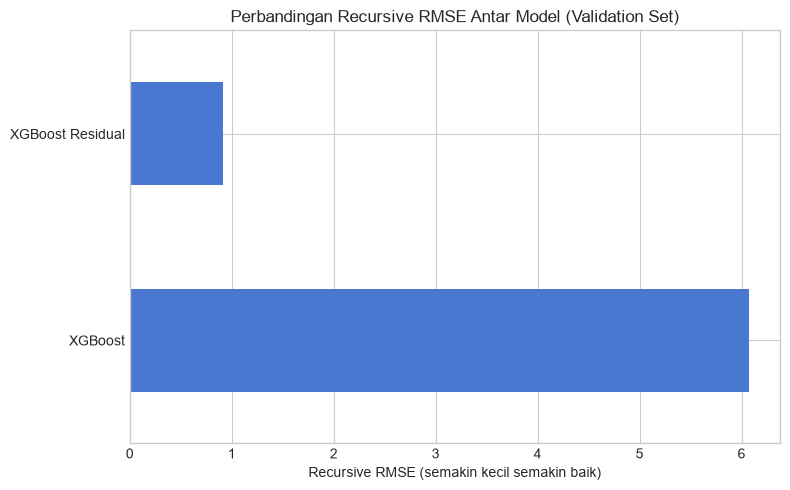

In [222]:
plt.figure(figsize=(8, 5))
score_df.sort_values('RMSE')['RMSE'].plot(kind='barh')
plt.xlabel('Recursive RMSE (semakin kecil semakin baik)')
plt.title('Perbandingan Recursive RMSE Antar Model (Validation Set)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Prediksi & Pembuatan File Submission (Prediction & Submission)

### 7.1 Analisis Kepentingan Fitur (Feature Importance Analysis)

**Justifikasi (Justification):**
Menampilkan pentingnya fitur bagi model (LightGBM, XGBoost, CatBoost) untuk memastikan keputusan pemodelan didasarkan pada fitur hidrologi yang logis secara fisik.

#### 7.1.1 Kepentingan Fitur LightGBM (LightGBM Feature Importance)

In [223]:
# importance_df = pd.DataFrame({
#     'feature': X_train.columns,
#     'importance': model_lgbm.feature_importances_
# }).sort_values('importance', ascending=False).head(20)
# 
# plt.figure(figsize=(10, 8))
# sns.barplot(data=importance_df, x='importance', y='feature')
# plt.title('20 Fitur Terpenting (LightGBM)')
# plt.tight_layout()
# plt.show()

#### 7.1.2 Kepentingan Fitur XGBoost (XGBoost Feature Importance)

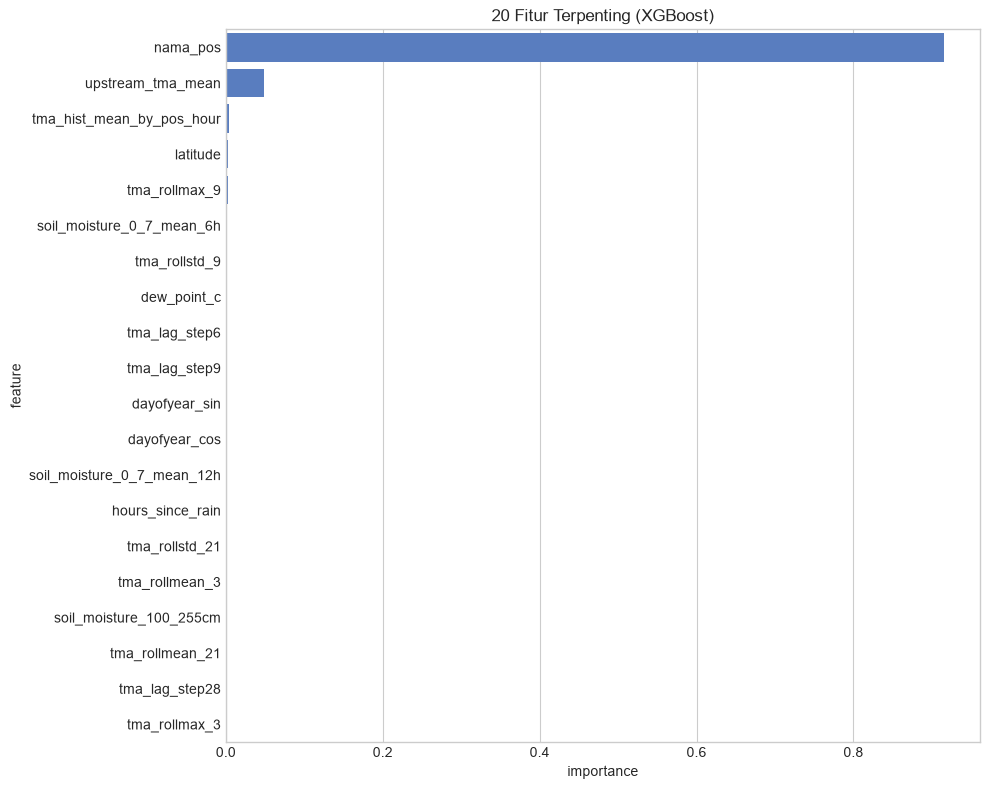

In [224]:
importance_df_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df_xgb, x='importance', y='feature')
plt.title('20 Fitur Terpenting (XGBoost)')
plt.tight_layout()
plt.show()

In [225]:
# Justifikasi Fitur XGBoost menggunakan SHAP
# import shap
# 
# Inisialisasi TreeExplainer untuk model XGBoost
# explainer_xgb = shap.TreeExplainer(model_xgb)
# shap_values_xgb = explainer_xgb(X_train)
# 
# Beeswarm plot untuk justifikasi arah pengaruh fitur
# plt.figure(figsize=(10, 8))
# shap.plots.beeswarm(shap_values_xgb, max_display=20, show=False)
# plt.title('Justifikasi Fitur XGBoost menggunakan SHAP (Beeswarm Plot)', fontsize=14)
# plt.tight_layout()
# plt.show()

#### 7.1.3 Kepentingan Fitur CatBoost (CatBoost Feature Importance)

In [226]:
# importance_df_cat = pd.DataFrame({
#     'feature': X_train.columns,
#     'importance': model_cat.feature_importances_
# }).sort_values('importance', ascending=False).head(20)
# 
# plt.figure(figsize=(10, 8))
# sns.barplot(data=importance_df_cat, x='importance', y='feature')
# plt.title('20 Fitur Terpenting (CatBoost)')
# plt.tight_layout()
# plt.show()

### 7.2 Pelatihan Ulang Model Final pada Seluruh Data (Final Model Retraining)

**Justifikasi (Justification):**
Melatih kembali model pada gabungan data latih dan validasi agar model mempelajari pola terbaru sebelum memprediksi data uji.

In [227]:
# hist_mean_map_full = train_full_sorted.assign(hour=train_full_sorted['datetime'].dt.hour) \
#     .groupby(['nama_pos', 'hour'])['tma_mdpl'].mean()
# hist_mean_map_full.name = 'tma_hist_mean_by_pos_hour'

# train_full_hist = tambah_fitur_historis(train_full_sorted, hist_mean_map_full)
# X_full = train_full_hist.drop(columns=['datetime', 'tma_mdpl'], errors='ignore')
# y_full = train_full_hist['tma_mdpl']
# X_full = X_full.drop(columns=['landcover_name'], errors='ignore')

# all_cats_ref = {}
# for col in cat_cols:
#     if col in X_full.columns:
#         X_full[col] = X_full[col].astype(str)
#         all_cats_ref[col] = pd.Categorical(X_full[col]).categories
#         X_full[col] = pd.Categorical(X_full[col], categories=all_cats_ref[col])

# final_col_order = X_full.columns.tolist()
# print(f'Bentuk data training final (train+val): {X_full.shape}')

# y_full_resid = y_full - X_full['tma_hist_mean_by_pos_hour']
# print('Target residual final sudah disiapkan.')

In [228]:
# model_lgbm_final = LGBMRegressor(n_estimators=model_lgbm.best_iteration_, learning_rate=LR, random_state=42,
#                                   objective='rmse', reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)
# model_lgbm_final.fit(X_full, y_full)
# print('LightGBM final selesai dilatih.')

# model_lgbm_resid_final = LGBMRegressor(n_estimators=model_lgbm.best_iteration_, learning_rate=LR, random_state=42,
#                                        objective='rmse', reg_alpha=0.1, reg_lambda=1.0, verbosity=-1)
# model_lgbm_resid_final.fit(X_full, y_full_resid)
# print('LightGBM final residual selesai dilatih.')

# model_xgb_resid_final = XGBRegressor(n_estimators=model_xgb_resid.best_iteration, learning_rate=LR, random_state=42,
#                                       objective='reg:squarederror', tree_method='hist', enable_categorical=True,
#                                       reg_alpha=0.1, reg_lambda=1.0)
# model_xgb_resid_final.fit(X_full, y_full_resid)
# print('XGBoost final residual selesai dilatih.')

# X_full_cb = X_full.copy()
# for col in cat_features_cb:
#     if col in X_full_cb.columns:
#         X_full_cb[col] = X_full_cb[col].astype(str)

# model_cat_resid_final = CatBoostRegressor(iterations=model_cat_resid.get_best_iteration(), learning_rate=LR, random_state=42,
#                                            loss_function='RMSE', cat_features=cat_features_cb, verbose=0)
# model_cat_resid_final.fit(X_full_cb, y_full_resid)
# print('CatBoost final residual selesai dilatih.')


In [229]:
# model_xgb_final = XGBRegressor(n_estimators=model_xgb.best_iteration, learning_rate=LR, random_state=42,
#                                 objective='reg:squarederror', tree_method='hist', enable_categorical=True,
#                                 reg_alpha=0.1, reg_lambda=1.0)
# model_xgb_final.fit(X_full, y_full)
# print('XGBoost final selesai dilatih.')

In [230]:
# X_full_cb = X_full.copy()
# for col in cat_features_cb:
#     if col in X_full_cb.columns:
#         X_full_cb[col] = X_full_cb[col].astype(str)

# model_cat_final = CatBoostRegressor(iterations=model_cat.get_best_iteration(), learning_rate=LR, random_state=42,
#                                      loss_function='RMSE', cat_features=cat_features_cb, verbose=0, l2_leaf_reg=3.0)
# model_cat_final.fit(X_full_cb, y_full)
# print('CatBoost final selesai dilatih.')

### 7.3 Batasan Nilai & Prediksi Rekursif Data Uji (Boundary Clipping & Recursive Inference)

Bagian ini menjalankan proses prediksi rekursif pada data uji. Kami menetapkan batas pemotongan (*clipping boundaries*) untuk membatasi nilai prediksi agar tetap berada dalam rentang historis yang wajar.

#### 7.3.1 Definisi Batasan Nilai (Boundary Clipping Definition)

**Justifikasi (Justification):**
Membatasi hasil prediksi rekursif dalam batas minimum/maksimum historis + margin 15% untuk mencegah nilai prediksi yang tidak masuk akal akibat akumulasi kesalahan prediksi.

In [231]:
# clip_margin = 0.15

# # Hitung batasan historis untuk pemotongan prediksi
# clip_bounds = {}
# for pos in daftar_pos:
#     series_pos = train_df.loc[train_df['nama_pos'] == pos, 'tma_mdpl']
#     lo = series_pos.min()
#     hi = series_pos.max()
#     span = hi - lo
#     clip_bounds[pos] = (lo - clip_margin * span, hi + clip_margin * span)

# print('Contoh batas clip:', dict(list(clip_bounds.items())[:3]))

#### 7.3.2 Prediksi Rekursif Data Uji (Recursive Test Prediction)

In [232]:
# MAXLAG = max(LAG_STEPS + ROLL_WINDOWS) + 1
# base_history_map = {}
# for pos in daftar_pos:
#     hist = train_df[train_df['nama_pos'] == pos].sort_values('datetime')['tma_mdpl'].tail(MAXLAG).tolist()
#     base_history_map[pos] = hist

# test_df_sorted = test_df.sort_values(['datetime', 'nama_pos']).reset_index(drop=True)
# unique_test_times = sorted(test_df_sorted['datetime'].unique())

# def build_feature_row(pos, dt, history_vals):
#     row = {}
#     hist_arr = np.array(history_vals, dtype=float)
#     n = len(hist_arr)
#     for step in LAG_STEPS:
#         row[f'tma_lag_step{step}'] = hist_arr[n - step] if n >= step else np.nan
#     for w in ROLL_WINDOWS:
#         window_vals = hist_arr[max(0, n - w):n]
#         row[f'tma_rollmean_{w}'] = np.mean(window_vals) if len(window_vals) else np.nan
#         row[f'tma_rollmax_{w}'] = np.max(window_vals) if len(window_vals) else np.nan
#         row[f'tma_rollmin_{w}'] = np.min(window_vals) if len(window_vals) else np.nan
#         row[f'tma_rollstd_{w}'] = np.std(window_vals) if len(window_vals) > 1 else 0.0
#     row['tma_diff_step1'] = (hist_arr[n - 1] - hist_arr[n - 2]) if n >= 2 else np.nan
#     row['nama_pos'] = pos
#     row['datetime'] = dt
#     return row

# def recursive_predict_test(model, initial_history_map, predict_fn=None):
#     local_history = {pos: hist.copy() for pos, hist in initial_history_map.items()}
#     preds = {}

#     for dt in unique_test_times:
#         rows_here = test_df_sorted.loc[test_df_sorted['datetime'] == dt, 'nama_pos'].tolist()
#         feat_rows = [build_feature_row(pos, dt, local_history[pos]) for pos in rows_here]
#         feat_df = pd.DataFrame(feat_rows)
#         feat_df = add_cyclical(feat_df)
#         feat_df = feat_df.merge(env_df[['nama_pos', 'datetime'] + env_feature_cols], on=['nama_pos', 'datetime'], how='left')
#         hour_tmp2 = feat_df['datetime'].dt.hour
#         feat_df = feat_df.merge(hist_mean_map_full, left_on=['nama_pos', hour_tmp2], right_index=True, how='left')
#         feat_df_model = feat_df.drop(columns=['datetime'], errors='ignore').drop(columns=['landcover_name'], errors='ignore')

#         for col in cat_cols:
#             if col in feat_df_model.columns:
#                 feat_df_model[col] = pd.Categorical(feat_df_model[col].astype(str), categories=all_cats_ref[col])

#         feat_df_model = feat_df_model.reindex(columns=final_col_order)

#         if predict_fn is not None:
#             pred_values = predict_fn(model, feat_df_model)
#         else:
#             pred_values = model.predict(feat_df_model)

#         for i, pos in enumerate(rows_here):
#             pred_value = pred_values[i]
#             lo, hi = clip_bounds.get(pos, (-np.inf, np.inf))
#             pred_value = min(max(pred_value, lo), hi)
#             preds[(pos, dt)] = pred_value
#             local_history[pos].append(pred_value)

#     return preds


# preds_test = {
#     'lgbm': recursive_predict_test(model_lgbm_final, base_history_map),
#     'xgb': recursive_predict_test(model_xgb_final, base_history_map),
#     'cat': recursive_predict_test(model_cat_final, base_history_map, predict_fn=predict_cat),
# }

#### 7.3.3 Prediksi Rekursif Model Residual (Residual Models Test Prediction)

In [233]:
# preds_test['lgbm_resid'] = recursive_predict_test(
#     model_lgbm_resid_final,
#     base_history_map,
#     predict_fn=predict_lgbm_resid,
# )
# preds_test['xgb_resid'] = recursive_predict_test(
#     model_xgb_resid_final,
#     base_history_map,
#     predict_fn=predict_xgb_resid,
# )
# preds_test['cat_resid'] = recursive_predict_test(
#     model_cat_resid_final,
#     base_history_map,
#     predict_fn=predict_cat_resid,
# )
# print('Prediksi rekursif model residual selesai.')

#### 7.3.4 Prediksi Ensemble Berbobot (Weighted Ensemble Prediction)

**Justifikasi (Justification):**  
Menggabungkan prediksi dari tiga model residual terbaik menggunakan bobot berdasarkan inverse recursive RMSE. Model dengan RMSE lebih rendah mendapat bobot lebih besar secara otomatis.


In [234]:
# # Hitung bobot ensemble berdasarkan inverse recursive RMSE
# resid_scores_ens = {
#     'lgbm_resid': rmse_recursive_lgbm_resid,
#     'xgb_resid':  rmse_recursive_xgb_resid,
#     'cat_resid':  rmse_recursive_cat_resid,
# }
# inv_s = {k: 1.0 / v for k, v in resid_scores_ens.items()}
# total_inv = sum(inv_s.values())
# ensemble_weights = {k: v / total_inv for k, v in inv_s.items()}
# print('Bobot ensemble (inverse RMSE weighted):')
# for k, w in ensemble_weights.items():
#     print(f'  {k}: {w:.3f}')

# # Gabungkan prediksi test secara berbobot
# all_test_keys = set(preds_test['lgbm_resid'].keys())
# preds_test['ensemble_resid'] = {
#     key: sum(ensemble_weights[m] * preds_test[m][key] for m in resid_scores_ens)
#     for key in all_test_keys
# }

# # Hitung recursive RMSE ensemble dari val_check masing-masing model residual
# # val_check berisi DataFrame dengan kolom 'tma_mdpl' (aktual) dan 'pred' (prediksi rekursif)
# val_check_ensemble = val_check_lgbm_resid[['nama_pos', 'datetime', 'tma_mdpl']].copy()
# val_check_ensemble['pred'] = (
#     ensemble_weights['lgbm_resid'] * val_check_lgbm_resid['pred'].values +
#     ensemble_weights['xgb_resid']  * val_check_xgb_resid['pred'].values +
#     ensemble_weights['cat_resid']  * val_check_cat_resid['pred'].values
# )
# rmse_recursive_ensemble = math.sqrt(mean_squared_error(
#     val_check_ensemble['tma_mdpl'], val_check_ensemble['pred']
# ))
# print(f'RMSE recursive ensemble (weighted val_check): {rmse_recursive_ensemble:.4f}')

# # Hitung juga one-step RMSE sebagai referensi tambahan
# preds_val_ens = (
#     ensemble_weights['lgbm_resid'] * np.array(pred_lgbm_resid_final) +
#     ensemble_weights['xgb_resid']  * np.array(pred_xgb_resid_final) +
#     ensemble_weights['cat_resid']  * np.array(pred_cat_resid_final)
# )
# rmse_ensemble_val = math.sqrt(mean_squared_error(y_val, preds_val_ens))
# print(f'RMSE ensemble one-step val (referensi): {rmse_ensemble_val:.4f}')
# print('Prediksi ensemble test selesai.')


#### 7.3.4 Identifikasi Model Terbaik (Best Model Identification)

In [235]:
# recursive_scores = {
#     'ensemble_resid': rmse_recursive_ensemble,
#     'lgbm': rmse_recursive_lgbm,
#     'xgb': rmse_recursive_xgb,
#     'cat': rmse_recursive_cat,
#     'lgbm_resid': rmse_recursive_lgbm_resid,
#     'xgb_resid': rmse_recursive_xgb_resid,
#     'cat_resid': rmse_recursive_cat_resid,
# }

# best_recursive_key = min(recursive_scores, key=recursive_scores.get)
# recursive_name_map = {
#     'ensemble_resid': 'Ensemble Berbobot (Residual)',
#     'lgbm': 'LightGBM',
#     'xgb': 'XGBoost',
#     'cat': 'CatBoost',
#     'lgbm_resid': 'LightGBM Residual',
#     'xgb_resid': 'XGBoost Residual',
#     'cat_resid': 'CatBoost Residual',
# }

# print(f"Model terbaik berdasarkan recursive RMSE: {recursive_name_map[best_recursive_key]} ({recursive_scores[best_recursive_key]:.4f})")

### 7.4 Pembuatan File Submission (Submission File Generation)

In [236]:
# model_key_map = {
#     'ensemble_resid': 'Ensemble Berbobot (Residual)',
#     'lgbm': 'LightGBM',
#     'lgbm_resid': 'LightGBM Residual',
#     'xgb': 'XGBoost',
#     'xgb_resid': 'XGBoost Residual',
#     'cat': 'CatBoost',
#     'cat_resid': 'CatBoost Residual',
# }

# # Pilih model terbaik berdasarkan recursive RMSE (termasuk ensemble_resid)
# best_key = best_recursive_key
# best_model_name = model_key_map[best_key]
# print(f"Model terpilih untuk submission: {best_model_name} (recursive RMSE: {recursive_scores[best_key]:.4f})")

# sub_rows = []
# for _, r in test_df_sorted.iterrows():
#     key = (r['nama_pos'], r['datetime'])
#     sub_rows.append({'id': r['id'], 'tma_mdpl': preds_test[best_key][key]})

# submission = pd.DataFrame(sub_rows)
# n_missing = submission['tma_mdpl'].isnull().sum()
# print(f'Jumlah baris NaN di submission: {n_missing} dari {len(submission)}')

# display(submission.head())
# print(f'\nTotal baris submission: {len(submission)}')
# submission.to_csv('submission.csv', index=False)
# print("File 'submission.csv' berhasil dibuat (memakai model terbaik recursive: " + best_model_name + ").")